## Base de librerías

In [1]:
# Instalaciones extra
#!pip install pysentimiento
#!pip install deep-translator
#!pip install rapidfuzz

In [1]:
# Importar librerías necesarias
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.offline as pyo
from scipy import stats
from scipy.stats import skew, kurtosis
from typing import List, Dict, Any, Optional
import warnings
warnings.filterwarnings('ignore')

# Para análisis de texto
import re
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import unicodedata
from transformers import pipeline
from rapidfuzz import process, fuzz
#from pysentimiento import create_analyzer
from deep_translator import GoogleTranslator

# Para análisis avanzado
from sklearn.preprocessing import StandardScaler,  MultiLabelBinarizer, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE


# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
nltk.download('stopwords')

# Intentar importar el módulo 'utils' añadiendo la carpeta padre al sys.path.
# Evita el uso de import relativo en notebooks (genera ImportError: attempted relative import with no known parent package).
import sys
import os

_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)

try:
    from utils.severity_classification import (
        zero_shot_severity_classification,
        process_list_of_texts
    )
except Exception:
    # Como fallback, intentar subir un nivel más (por si el notebook se ejecuta desde una subcarpeta distinta)
    _root2 = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if _root2 not in sys.path:
        sys.path.insert(0, _root2)
    from utils.severity_classification import (
        zero_shot_severity_classification,
        process_list_of_texts
    )

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/andrewpg/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Carga de datos

In [2]:
#@title Cargar el dataset
df = pd.read_excel('../data/OPERA_BASE.xlsx')

# Mostrar información básica
print("INFORMACIÓN BÁSICA DEL DATASET")
print("=" * 50)
print(f"Forma del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Tipos de datos:")
print(df.dtypes.value_counts())
print("\nPrimeras 5 filas:")
df.head()


INFORMACIÓN BÁSICA DEL DATASET
Forma del dataset: 30962 filas × 64 columnas
Memoria utilizada: 88.28 MB
Tipos de datos:
str               49
int64             10
float64            3
datetime64[us]     1
object             1
Name: count, dtype: int64

Primeras 5 filas:


,Documento PMD,Número de episodio,Nombres y Apellidos,Tipo de identificación,Número de identificación,Especialidad,Aseguradora,Fecha,Hora,Edad,Sexo,Peso (Kg),Talla (cm),IMC,Atención,Ingreso,Dx Preoperatorio,Grupo Sanguíneo,RH,Condición,Medicamentos,Nombre del medicamento,Dosis,Tiempo Uso,Alergias,Alérgeno,Antecedentes anestésicos,Antecedentes quirúrgicos,Anestesia previa,Antecedente neurológicos,Antecedente respiratorios,Antecedentes cardiovasculares,Antecedente hematológicos,Antecedente endocrinológicos,Antecedente renales,Antecedente gastrointestinales,Clasificación Estado Físico ASA,Clase Funcional (NYHA),Procedimiento propuesto,Tensión Arterial Sistólica (mm/Hg),Tensión Arterial Diastólica (mm/Hg),Tensión Arterial Media (mm/Hg),Frecuencia Respiratoria,Temperatura,Cuello Móvil,Prótesis Dental,Apertura Oral,Puntaje Mallampati,Estado Nutricional,Color de Piel,Sistema Nervioso,Apertura Visual,Respuesta Verbal,Respuesta Motora,Sistema Respiratorio,Sistema cardiovascular,Arritmia,Abdomen,Exámenes de laboratorio,Examen,Resultado de examen de laboratorio,Tipo de anestesia propuesta,Disnea,Angina
0,1000025798051,5926080,ANDRES EDUARDO RUEDA FAJARDO,CC,4652930,ANESTESIOLOGIA,PARTICULAR PLENO,2019-01-01,13:36:27,49,M,78,172,26.4,Urgencia,Ambulatorio,EXPLOSION DE POLVORA EN MANO IZQUIERDA.,Sin Dato,Sin Dato,NaN,No,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Negativo;;;;;;;,Negativo;;;;;;,Negativo;;;,Negativo;;;,Negativo;;;,I,I,"CURETAJE, AMPUTACIÓN Y REMODELACION DE COLGAJO...",0,0,0,0,0.0,Normal,No,> 3 cm,2,Normal,Normal,Normal,NaN,NaN,NaN,Normal;;;,Normal,No,Normal,No tiene,NaN,NaN,General,NaN,NaN
1,1000025801070,5918846,LUZ ELENA LOPEZ ARRUBLA,CC,66922871,ANESTESIOLOGIA,COLMEDICA MEDICINA PREPAGADA,2019-01-02,07:18:28,43,F,58,153,0.0,Electivo,Ambulatorio,ADENOMIOSIS,Sin Dato,Sin Dato,NaN,Si,NINGUNO,NaN,NaN,No,NaN,2012.0,ABDOMINOPLASTIA,AG,NaN,NaN,Negativo;;;;;;;,Negativo;;;;;;,Negativo;;;,Negativo;;;,Negativo;;;,I,I,HISTERECTOMIA LAPAROSCOPICA,100,60,0,0,0.0,Normal,No,> 3 cm,1,Normal,Normal,Normal,NaN,NaN,NaN,Normal;;;,Normal,No,Normal,No tiene,NaN,NaN,General,NaN,NaN
2,1000025801183,5926027,FERNANDO BECERRA ARIZA,CC,91280389,ANESTESIOLOGIA,AXA COLPATRIA MEDICINA PREPAGADA SA,2019-01-02,07:28:08,47,M,103,189,0.0,Urgencia,Ambulatorio,FRACTURA DE CLAVICULA.,Sin Dato,Sin Dato,NaN,No,NaN,NaN,NaN,Si,"DIPIRONA, DICLOFENAC,ASA,AINES",2016.0,MENISCOPLASTIA RODILLA IZQUIERDA.,"SEDACIÓN, INTRAARTICULAR",NaN,NaN,Negativo;;;;;;;,Negativo;;;;;;,Negativo;;;,Negativo;;;,Gastritis,I,I,OTS CLAVICULA DERECHA.,0,0,0,0,0.0,Normal,No,> 3 cm,1,Normal,Normal,NaN,NaN,NaN,NaN,Normal;;;,Normal,No,Normal,No tiene,NaN,NaN,General,NaN,NaN
3,1000025801196,5917159,ELBAR RAMIREZ,CC,16681375,ANESTESIOLOGIA,UNIVERSIDAD NACIONAL DE COLOMBIA,2019-01-02,07:29:42,56,M,60,173,0.0,Electivo,Ambulatorio,HPB,Sin Dato,Sin Dato,NaN,Si,NINGUNO,NaN,NaN,No,NaN,2004.0,RESECCION QUISTE INGUINAL,AG,NaN,NaN,Negativo;;;;;;;,Negativo;;;;;;,Negativo;;;,Negativo;;;,Negativo;;;,I,I,RTU DE PRÓSTATA,120,70,0,0,0.0,Normal,No,> 3 cm,1,Normal,Normal,Normal,NaN,NaN,NaN,Normal;;;,Normal,No,Normal,No tiene,NaN,NaN,Raquídea,NaN,NaN
4,1000025801354,5914285,LADY JHOANA GIRALDO SARRIA,CC,31713156,ANESTESIOLOGIA,COOMEVA MEDICINA PREPAGA S.A.,2019-01-02,07:39:12,35,F,63,155,0.0,Electivo,Ambulatorio,EMB A TERMINO .,Sin Dato,Sin Dato,NaN,Si,MICRONUTRIENTES .,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Negativo;;;;;;;,Negativo;;;;;;,Negativo;;;,Negativo;;;,R.G.E.,I,I,CESAREA .,110,60,0,0,0.0,Normal,No,> 3 cm,1,Normal,Normal,Normal,NaN,NaN,NaN,Normal;;;,Normal,No,Normal,Si tiene,Hemoglobina(g/dl),12,Raquídea,NaN,NaN


## Funciones generales

### Control y calidad

In [3]:
def get_data_quality_report(df):
    """Genera un reporte de calidad de datos"""
    report = {
        'shape': df.shape,
        'memory_usage': df.memory_usage(deep=True).sum() / 1024**2,
        'missing_data': df.isnull().sum().to_dict(),
        'duplicate_rows': df.duplicated().sum(),
        'data_types': df.dtypes.value_counts().to_dict()
    }
    return report

def summarize_series(series: pd.Series) -> Dict[str, Any]:
    """Resumen compacto para una serie."""
    non_null = series.dropna()
    summary = {
        'tipo': str(series.dtype),
        'n_total': len(series),
        'n_nulos': series.isna().sum(),
        'unicos': series.nunique(dropna=True),
    }
    if np.issubdtype(series.dtype, np.number):
        if len(non_null) > 0:
            summary.update({
                'min': float(non_null.min()),
                'p25': float(non_null.quantile(0.25)),
                'mediana': float(non_null.median()),
                'media': float(non_null.mean()),
                'p75': float(non_null.quantile(0.75)),
                'max': float(non_null.max()),
                'std': float(non_null.std(ddof=1)) if len(non_null) > 1 else 0.0,
            })
    else:
        # Top 3 categorías más frecuentes (para categóricas/texto)
        vc = series.astype(str).value_counts(dropna=True).head(3)
        topk = ', '.join([f"{idx} ({cnt})" for idx, cnt in vc.items()])
        summary['top3'] = topk
    return summary


def compare_columns_impact(df_before: pd.DataFrame,
                           df_after: pd.DataFrame,
                           columns: List[str],
                           show_value_diffs: bool = True,
                           top_k: int = 5,
                           sample_rows: int = 5) -> Dict[str, Any]:
    """
    Compara el impacto de limpieza para columnas específicas entre dos DataFrames.

    Args:
        df_before: DataFrame antes de la limpieza
        df_after: DataFrame después de la limpieza
        columns: Columnas a comparar
        show_value_diffs: Si muestra diferencias de valores frecuentes
        top_k: Top-k valores más frecuentes para comparar (categóricas)
        sample_rows: Muestras de filas con cambios (si aplica)

    Returns:
        Diccionario con:
        - overview: tabla general por columna (DataFrame)
        - value_diffs: dict de DataFrames por columna (frecuencias top-k)
        - changed_rows_samples: dict de DataFrames con ejemplos de cambios
    """
    results: Dict[str, Any] = {
        'overview': None,
        'value_diffs': {},
        'changed_rows_samples': {}
    }

    overview_rows = []

    # Alinear índices por seguridad
    df_b = df_before.copy()
    df_a = df_after.copy()

    # Intersección de columnas e índices
    cols = [c for c in columns if c in df_b.columns and c in df_a.columns]
    common_index = df_b.index.intersection(df_a.index)

    for col in cols:
        s_b = df_b.loc[common_index, col]
        s_a = df_a.loc[common_index, col]

        # Resúmenes
        sum_b = summarize_series(s_b)
        sum_a = summarize_series(s_a)

        # Cambios básicos
        row = {
            'columna': col,
            'tipo_antes': sum_b.get('tipo'),
            'tipo_despues': sum_a.get('tipo'),
            'n_total': sum_b.get('n_total'),
            'nulos_antes': sum_b.get('n_nulos'),
            'nulos_despues': sum_a.get('n_nulos'),
            'Δ_nulos': sum_a.get('n_nulos') - sum_b.get('n_nulos'),
            'unicos_antes': sum_b.get('unicos'),
            'unicos_despues': sum_a.get('unicos'),
            'Δ_unicos': sum_a.get('unicos') - sum_b.get('unicos'),
        }

        # Numéricas: métricas clave y deltas
        if np.issubdtype(s_b.dtype, np.number) or np.issubdtype(s_a.dtype, np.number):
            for k in ['min', 'p25', 'mediana', 'media', 'p75', 'max', 'std']:
                row[f'{k}_antes'] = sum_b.get(k)
                row[f'{k}_despues'] = sum_a.get(k)
                if (sum_b.get(k) is not None) and (sum_a.get(k) is not None):
                    try:
                        row[f'Δ_{k}'] = round(sum_a.get(k) - sum_b.get(k), 6)
                    except Exception:
                        row[f'Δ_{k}'] = None
                else:
                    row[f'Δ_{k}'] = None
        else:
            # Categóricas: top3 antes/después
            row['top3_antes'] = sum_b.get('top3', '')
            row['top3_despues'] = sum_a.get('top3', '')

        # Ejemplos de cambios a nivel fila (donde difiere el valor)
        changed_mask = (s_b.astype(str) != s_a.astype(str)) & ~(s_b.isna() & s_a.isna())
        changed_idx = common_index[changed_mask]
        if len(changed_idx) > 0:
            sample_idx = changed_idx[:sample_rows]
            sample_df = pd.DataFrame({
                'antes': s_b.loc[sample_idx].values,
                'despues': s_a.loc[sample_idx].values
            }, index=sample_idx)
            results['changed_rows_samples'][col] = sample_df

        # Diferencias en frecuencias de valores (categóricas y num discretizadas)
        if show_value_diffs:
            if not np.issubdtype(s_b.dtype, np.number):
                vb = s_b.astype(str).value_counts().head(top_k)
                va = s_a.astype(str).value_counts().head(top_k)
                value_diff = pd.DataFrame({
                    'freq_antes': vb,
                    'freq_despues': va
                }).fillna(0).astype(int)
                results['value_diffs'][col] = value_diff
            else:
                # Para numéricas: comparar bines
                try:
                    bins = 10
                    vb = pd.cut(s_b, bins=bins).value_counts().sort_index()
                    va = pd.cut(s_a, bins=bins).value_counts().sort_index()
                    value_diff = pd.DataFrame({
                        'freq_antes': vb,
                        'freq_despues': va
                    }).fillna(0).astype(int)
                    results['value_diffs'][col] = value_diff
                except Exception:
                    pass

        overview_rows.append(row)

    results['overview'] = pd.DataFrame(overview_rows)
    return results

def get_new_columns(before_df: pd.DataFrame, after_df: pd.DataFrame):
    """Devuelve lista de columnas nuevas creadas en after_df."""
    return [c for c in after_df.columns if c not in before_df.columns]


def plot_columns_distributions(df: pd.DataFrame,
                               columns: list,
                               top_k: int = 12,
                               bins: int = 30,
                               max_plots: int = 12,
                               figsize=(16, 10)):
    """
    Grafica distribución (numéricas) o frecuencias (categóricas) para columnas dadas.
    """
    cols = columns[:max_plots]
    if len(cols) == 0:
        print("No hay columnas para graficar.")
        return

    n = len(cols)
    ncols = 3 if n >= 3 else n
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], max(figsize[1], 3*nrows)))
    if nrows == 1:
        axes = [axes] if ncols == 1 else axes
    else:
        axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col]
        if np.issubdtype(s.dtype, np.number):
            sns.histplot(s.dropna(), bins=bins, kde=True, ax=ax, color='#69b3a2')
            ax.set_title(f"Distribución: {col}")
            ax.set_xlabel(col)
            ax.set_ylabel('Frecuencia')
        else:
            vc = s.astype(str).value_counts().head(top_k)
            sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='Set3')
            ax.set_title(f"Top {min(top_k, len(vc))} frecuencias: {col}")
            ax.set_xlabel('Frecuencia')
            ax.set_ylabel('Valor')
        ax.grid(True, alpha=0.2)

    # Ocultar axes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def visualize_new_columns(before_df: pd.DataFrame,
                          after_df: pd.DataFrame,
                          top_k: int = 12,
                          bins: int = 30,
                          max_plots: int = 12,
                          figsize=(16, 10)):
    """
    Detecta columnas nuevas en after_df y grafica su distribución/frecuencia.
    """
    new_cols = get_new_columns(before_df, after_df)
    if len(new_cols) == 0:
        print("No se detectaron columnas nuevas.")
        return []

    print(f"Columnas nuevas detectadas ({len(new_cols)}): {new_cols[:max_plots]}" + (" ..." if len(new_cols) > max_plots else ""))
    plot_columns_distributions(after_df, new_cols, top_k=top_k, bins=bins, max_plots=max_plots, figsize=figsize)
    return new_cols

def log_changes(before_df: pd.DataFrame,
                        after_df: pd.DataFrame,
                        func_name: str,
                        show: bool = True) -> pd.DataFrame:
    """
    Tabla compacta de cambios generales tras aplicar una función.
    """
    changes = {
        'funcion': [func_name],
        'filas_antes': [len(before_df)],
        'filas_despues': [len(after_df)],
        'Δ_filas': [len(after_df) - len(before_df)],
        'cols_antes': [len(before_df.columns)],
        'cols_despues': [len(after_df.columns)],
        'Δ_cols': [len(after_df.columns) - len(before_df.columns)],
        'nuevas_cols': [', '.join(sorted(set(after_df.columns) - set(before_df.columns)))[:200]],
        'cols_removidas': [', '.join(sorted(set(before_df.columns) - set(after_df.columns)))[:200]],
    }
    table = pd.DataFrame(changes)
    if show:
        display(table)
    return table


### Limpieza de texto

In [4]:
def remove_stopwords_es(text, extra_stopwords=None):
    """
    Elimina stopwords en español de un texto.

    Args:
        text (str): Texto de entrada.
        extra_stopwords (list): Lista adicional de palabras a eliminar (opcional).

    Returns:
        str: Texto sin stopwords.
    """
    if not isinstance(text, str):
        return ""

    # Tokenización básica
    tokens = re.findall(r'\b\w+\b', text.lower())

    # Stopwords estándar + adicionales
    stop_words = set(stopwords.words('spanish'))
    if extra_stopwords:
        stop_words.update([w.lower() for w in extra_stopwords])

    # Filtrar
    filtered = [word for word in tokens if word not in stop_words]
    return " ".join(filtered)


def remove_accents(text):
    """Elimina acentos y caracteres especiales del texto"""
    if pd.isna(text):
        return text
    nfkd_form = unicodedata.normalize('NFKD', str(text))
    only_ascii = nfkd_form.encode('ASCII', 'ignore').decode('ASCII')
    return only_ascii

def to_lower(text):
    """Convierte texto a minúsculas"""
    if pd.isna(text):
        return text
    return str(text).lower()

def remove_non_letters(text, ignore_chars=[], replace_char=''):
    """Elimina caracteres no alfabéticos, conservando los especificados"""
    if pd.isna(text):
        return text
    ignore_pattern = ''.join(re.escape(char) for char in ignore_chars)
    pattern = rf'[^a-zA-Z{ignore_pattern}\s]'
    return re.sub(pattern, replace_char, str(text))

def clean_whitespace(text):
    """Limpia espacios en blanco múltiples y al inicio/final"""
    if pd.isna(text):
        return text
    return ' '.join(str(text).split())

def map_variable(value, categories, default='otros'):
    """Mapeo de variables en ciertass categorías"""
    for key, variants in categories.items():
        if value in variants:
            return key
    return default

def normalize_tokens(text, word_map):
    """Normaliza tokens de texto para homogeneizar categorías"""
    s = str(text).lower().strip()
    # reemplazos con límites de palabra para evitar tocar subcadenas indeseadas
    for wrong, right in word_map.items():
        s = re.sub(rf"\b{re.escape(wrong)}\b", right, s)
    return s


def classify_dinamyc(text, rules, default = 'otros'):
    """Clasifica dinámicamente en un set de reglas [([<palabras que debe contener>], <resultado>)],...]"""
    if pd.isna(text):
        return default

    for key_words, category in rules:
        if all(word in text for word in key_words):
            return category

    return default

def create_multi_label(text, labels, default = 'otros'):
    """Crea una variable multilabel a partir de un texto"""
    if pd.isna(text):
        return default

    result = []
    for label in labels:
        if label in text:
            result.append(label)

    if not result:
        return default

    return ', '.join(result)

def resolve_contradictory_term(text, delimiter, contradictory_term='negativo'):
    items = [i.strip() for i in text.split(delimiter) if i.strip()]
    items = list(set(items))  # eliminar duplicados

    # Si hay términos contradictorios y otros, se eliminan los contradictorios
    if (contradictory_term in items) and len(items) > 1:
        items = [i for i in items if i != contradictory_term]

    return delimiter.join(items)

def standardize_text(text, remove_accents_flag=True, to_lower_flag=True, clean_whitespace_flag=True, remove_non_letters_flag=True, ignore_chars=[], replace_char=''):
    """Función general para estandarizar texto"""
    if pd.isna(text):
        return text

    result = str(text)

    if remove_accents_flag:
        result = remove_accents(result)
    if to_lower_flag:
        result = to_lower(result)
    if clean_whitespace_flag:
        result = clean_whitespace(result)
    if remove_non_letters_flag:
        result = remove_non_letters(result, ignore_chars, replace_char)

    return result

### Limpieza de números

In [22]:
def convert_to_numeric(df, columns, errors='coerce'):
    """Convierte columnas a tipo numérico"""
    df_copy = df.copy()
    for col in columns:
        if col in df_copy.columns:
            df_copy[col] = pd.to_numeric(df_copy[col], errors=errors)
    return df_copy

def detect_outliers_iqr(series, factor=1.5):
    """Detecta outliers usando el método IQR"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return (series < lower_bound) | (series > upper_bound)

def detect_outliers_zscore(series, threshold=3):
    """Detecta outliers usando Z-score"""
    z_scores = np.abs(stats.zscore(series.dropna()))
    return z_scores > threshold

def remove_outliers(df, columns, method='iqr', **kwargs):
    """Elimina outliers de columnas numéricas"""
    df_copy = df.copy()

    for col in columns:
        if col in df_copy.columns and df_copy[col].dtype in ['int64', 'float64']:
            if method == 'iqr':
                outliers = detect_outliers_iqr(df_copy[col], **kwargs)
            elif method == 'zscore':
                outliers = detect_outliers_zscore(df_copy[col], **kwargs)
            else:
                continue

            df_copy = df_copy[~outliers]

    return df_copy

def clip_outliers(df, columns, method='iqr', **kwargs):
    """Recorta outliers en lugar de eliminarlos"""
    df_copy = df.copy()

    for col in columns:
        if col in df_copy.columns and df_copy[col].dtype in ['int64', 'float64']:
            if method == 'iqr':
                Q1 = df_copy[col].quantile(0.25)
                Q3 = df_copy[col].quantile(0.75)
                IQR = Q3 - Q1
                factor = kwargs.get('factor', 1.5)
                lower_bound = Q1 - factor * IQR
                upper_bound = Q3 + factor * IQR
                df_copy[col] = df_copy[col].clip(lower_bound, upper_bound)

    return df_copy

def validate_numeric_ranges(df, columns, ranges):
    """Valida que los valores estén en rangos lógicos"""
    df_copy = df.copy()

    for col in columns:
        if col in df_copy.columns and col in ranges:
            min_val, max_val = ranges[col]
            df_copy[col] = df_copy[col].clip(min_val, max_val)

    return df_copy

import numpy as np

def validate_numeric_ranges_with_noise(df, columns, ranges, ruido_pct=0.05, seed=None):
    df_copy = df.copy()
    if seed is not None:
        np.random.seed(seed)

    for col in columns:
        if col in df_copy.columns and col in ranges:
            # 1. Asegurar que la columna sea float para permitir decimales del ruido
            df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce').astype(float)
            
            min_val, max_val = ranges[col]
            
            # 2. Identificar fuera de rango (incluyendo NaNs para que no rompan la máscara)
            # Solo imputamos si NO es nulo y está fuera del rango
            mask_fuera = ~df_copy[col].between(min_val, max_val) & df_copy[col].notna()
            
            n_imputar = mask_fuera.sum()
            
            if n_imputar > 0:
                rango = max_val - min_val
                # 3. Generar ruido y valores base
                # Usamos np.random.default_rng para mayor consistencia en versiones nuevas
                ruido = np.random.uniform(-ruido_pct, ruido_pct, size=n_imputar)
                
                # Cálculo de nuevos valores
                random_base = np.random.rand(n_imputar)
                imputados = (min_val + rango * random_base) * (1 + ruido)
                
                # 4. Asignación segura con .loc y clip
                df_copy.loc[mask_fuera, col] = np.clip(imputados, min_val, max_val)

    return df_copy

def eliminar_outliers(df, columnas, factor=1.5):
    """
    Elimina filas con outliers en cualquier columna numérica usando el método IQR.
    """
    df_copy = df.copy()
    for col in columnas:
        if col in df_copy.columns and df_copy[col].dtype in ['float64', 'int64']:
            Q1 = df_copy[col].quantile(0.25)
            Q3 = df_copy[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - factor * IQR
            upper = Q3 + factor * IQR
            mask = (df_copy[col] >= lower) & (df_copy[col] <= upper)
            df_copy = df_copy[mask]
    return df_copy

### Imputación y encoding

In [6]:
def impute(df, columns, value='negativo'):
    """Imputa valores faltantes con un valor personalizado"""
    df_copy = df.copy()
    for col in columns:
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].fillna(value)
    return df_copy

def encode_multilabel(df, column, delimiter=','):
    """Codifica variables multilabel"""
    df_copy = df.copy()

    # Separar en listas
    values = df_copy[column].apply(lambda x: [i.strip() for i in str(x).split(delimiter) if i.strip()])
    encoder = MultiLabelBinarizer()
    encoded = pd.DataFrame(
        encoder.fit_transform(values),
        columns=[f"{column}_{cls}" for cls in encoder.classes_],
        index=df_copy.index
    )

    return pd.concat([df_copy, encoded], axis=1)

def encode_onehot(df, column):
    """Codifica variables categóricas con one-hot encoding"""
    df_copy = df.copy()

    encoder = OneHotEncoder(sparse_output=False, dtype=int)
    reshaped = df_copy[[column]]
    encoded_array = encoder.fit_transform(reshaped)
    encoded = pd.DataFrame(
        encoded_array,
        columns=[f"{column}_{cls}" for cls in encoder.categories_[0]],
        index=df_copy.index
    )

    return pd.concat([df_copy, encoded], axis=1)

def encode_label(df, column):
    """Codifica variables categóricas con label encoding"""
    df_copy = df.copy()
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    df_copy[f"{column}_encoded"] = le.fit_transform(df_copy[column].astype(str))
    return df_copy

def encode_label_with_classes(df, column, classes):
    """
    Codifica una columna categórica usando clases definidas explícitamente.
    Args:
        df (pd.DataFrame): DataFrame original.
        column (str): Nombre de la columna a codificar.
        classes (list): Lista de clases en el orden deseado.
    Returns:
        pd.DataFrame: Copia del DataFrame con columna codificada.
    """
    df_copy = df.copy()
    encoder = OrdinalEncoder(categories=[classes])
    df_copy[f"{column}_encoded"] = encoder.fit_transform(df_copy[[column]])
    return df_copy

## Funciones específicas

### Paciente y valoración

In [24]:
def imputar_fuera_de_rango(df, rangos_por_edad, edad_col='Edad', ruido_pct=0.03, seed=42):
    np.random.seed(seed)
    df_copy = df.copy()
    
    # --- MEJORA 1: Asegurar tipos numéricos para evitar errores de asignación ---
    cols_monitoreo = ['Peso (Kg)', 'Talla (cm)', 'IMC', edad_col]
    for col in cols_monitoreo:
        if col in df_copy.columns:
            df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce').astype(float)

    df_copy['recalculado_flag'] = False
    
    # --- MEJORA 2: Manejo de división por cero en IMC inicial ---
    # Evitamos errores si Talla es 0 o NaN
    talla_m = df_copy['Talla (cm)'] / 100
    imc_calculado = np.where(talla_m > 0, df_copy['Peso (Kg)'] / (talla_m ** 2), np.nan)
    
    for grupo in rangos_por_edad:
        # Máscara de edad
        edad_mask = (
            (df_copy[edad_col] >= grupo["edad_min"]) & 
            (df_copy[edad_col] <= grupo["edad_max"]) & 
            df_copy[edad_col].notna()
        )
        
        if not edad_mask.any():
            continue
        
        # Identificar fuera de rango
        peso_fuera = (df_copy['Peso (Kg)'] < grupo["peso"][0]) | (df_copy['Peso (Kg)'] > grupo["peso"][1]) | df_copy['Peso (Kg)'].isna()
        talla_fuera = (df_copy['Talla (cm)'] < grupo["talla"][0]) | (df_copy['Talla (cm)'] > grupo["talla"][1]) | df_copy['Talla (cm)'].isna()
        
        # Para IMC usamos el imc_calculado previamente
        imc_serie = pd.Series(imc_calculado, index=df_copy.index)
        imc_fuera = (imc_serie < grupo["imc"][0]) | (imc_serie > grupo["imc"][1]) | imc_serie.isna()
        
        mask_imputar = edad_mask & (peso_fuera | talla_fuera | imc_fuera)
        n_impute = mask_imputar.sum()
        
        if n_impute > 0:
            peso_mean = np.mean(grupo["peso"])
            talla_mean = np.mean(grupo["talla"])
            imc_mean = np.mean(grupo["imc"])
            
            # Generar e imputar (ahora seguro porque las columnas son float)
            df_copy.loc[mask_imputar, 'Peso (Kg)'] = peso_mean * (1 + np.random.uniform(-ruido_pct, ruido_pct, n_impute))
            df_copy.loc[mask_imputar, 'Talla (cm)'] = talla_mean * (1 + np.random.uniform(-ruido_pct, ruido_pct, n_impute))
            df_copy.loc[mask_imputar, 'IMC'] = imc_mean * (1 + np.random.uniform(-ruido_pct, ruido_pct, n_impute))
            df_copy.loc[mask_imputar, 'recalculado_flag'] = True
        
        # --- MEJORA 3: Recálculo de IMC consistente ---
        mask_recalc = edad_mask & ~mask_imputar & (df_copy['Talla (cm)'] > 0)
        if mask_recalc.any():
            df_copy.loc[mask_recalc, 'IMC'] = (
                df_copy.loc[mask_recalc, 'Peso (Kg)'] / 
                ((df_copy.loc[mask_recalc, 'Talla (cm)'] / 100) ** 2)
            )
    
    return df_copy



def _parse_hora(s):
    if pd.isna(s): return pd.NaT
    try:
        return pd.to_datetime(str(s)).time()
    except Exception:
        for fmt in ("%H:%M", "%H:%M:%S"):
            try:
                return pd.to_datetime(str(s), format=fmt, errors='raise').time()
            except Exception:
                continue
    return pd.NaT

def _nyha_to_int(x):
    return x.replace('I','0').replace('II','1').replace('III','2').replace('IV','3')

def clean_fecha_hora(df):
    dfc = df.copy()
    dfc["anio"] = dfc["Fecha"].dt.year
    dfc["mes"] = dfc["Fecha"].dt.month
    dfc["dia_semana"] = dfc["Fecha"].dt.dayofweek

    dfc["Hora"] = dfc["Hora"].apply(_parse_hora)
    dfc["Hora_decimal"] = dfc["Hora"].apply(lambda x: x.hour + x.minute/60 if pd.notna(x) else np.nan)

    dfc = dfc.drop(columns=["Fecha", "Hora"])

    log_changes(df, dfc, "clean__fecha_hora", True)

    return dfc

def clean_sexo_atencion(df):
    dfc = df.copy()
    dfc = encode_label_with_classes(dfc, 'Sexo', classes=['M', 'F'])
    dfc = encode_label_with_classes(dfc, 'Atención', classes=['Electivo', 'Urgencia', 'Urgencia Programada'])

    dfc = dfc.drop(columns=["Sexo", "Atención"])

    log_changes(df, dfc, "clean_sexo_atencion", True)

    return dfc

def clean_variables_fisiologicas(df):
    dfc = df.copy()

    num_cols = [
        'Edad', 'Peso (Kg)', 'Talla (cm)', 'IMC',
        'Tensión Arterial Sistólica (mm/Hg)', 'Tensión Arterial Diastólica (mm/Hg)',
        'Tensión Arterial Media (mm/Hg)', 'Frecuencia Respiratoria', 'Temperatura'
    ]
    dfc = convert_to_numeric(dfc, num_cols, errors='coerce')

    rangos_por_edad = [
        {"edad_min": 0, "edad_max": 2, "peso": (2, 20), "talla": (50, 95), "imc": (12, 20)},
        {"edad_min": 3, "edad_max": 10, "peso": (10, 50), "talla": (80, 140), "imc": (13, 22)},
        {"edad_min": 11, "edad_max": 17, "peso": (30, 90), "talla": (120, 180), "imc": (14, 28)},
        {"edad_min": 18, "edad_max": 110, "peso": (40, 300), "talla": (140, 230), "imc": (15, 40)},
    ]

    vital_ranges = {
        'Tensión Arterial Sistólica (mm/Hg)': (60, 260),
        'Tensión Arterial Diastólica (mm/Hg)': (30, 160),
        'Frecuencia Respiratoria': (10, 60),
        'Temperatura': (26, 43),
        'Edad': (0, 110)
    }

    dfc = validate_numeric_ranges_with_noise(dfc, list(vital_ranges.keys()), vital_ranges, ruido_pct=0.03, seed=42)
    dfc = imputar_fuera_de_rango(dfc, rangos_por_edad)

    # Recalcular TAM si está fuera de rango
    tam = (dfc['Tensión Arterial Sistólica (mm/Hg)'] + 2 * dfc['Tensión Arterial Diastólica (mm/Hg)']) / 3
    ok = dfc['Tensión Arterial Media (mm/Hg)'].between(40, 200)
    dfc['Tensión Arterial Media (mm/Hg)'] = np.where(ok, dfc['Tensión Arterial Media (mm/Hg)'], tam)

    log_changes(df, dfc, "clean_variables_fisiologicas", True)

    return dfc

def clean_grupo_rh_y_nyha(df):
    dfc = df.copy()
    dfc = encode_onehot(dfc, 'Grupo Sanguíneo')
    dfc = encode_onehot(dfc, 'RH')
    dfc = dfc.rename(columns={"Clase Funcional (NYHA) ": 'Clase Funcional (NYHA)'})
    dfc['NYHA_num'] = dfc['Clase Funcional (NYHA)'].apply(_nyha_to_int)
    dfc = dfc.drop(columns=["Grupo Sanguíneo", "RH", "Clase Funcional (NYHA)"])

    log_changes(df, dfc, "clean_grupo_rh_y_nyha", True)

    return dfc


### Antecedentes

In [8]:
def clean_antecedente(df, column):
    """Limpia variables de antecedentes específicamente"""
    def clean(text):
        text = standardize_text(text, ignore_chars=[','])
        text = text.replace(";", ",")
        return resolve_contradictory_term(text, ',')

    df_copy = df.copy()

    # Llenar nulos y limpiar texto
    df_copy[column] = impute(df_copy, [column], value='negativo')[column]
    df_copy[column] = df_copy[column].apply(clean)

    return encode_multilabel(df_copy, column, delimiter=',')

def clean_antecedentes_all(df, columns=['Antecedente neurológicos', 'Antecedente respiratorios', 'Antecedentes cardiovasculares',
                                        'Antecedente hematológicos ', 'Antecedente endocrinológicos', 'Antecedente renales',
                                        'Antecedente gastrointestinales']):
    df_copy = df.copy()
    for col in columns:
        if col in df_copy.columns:
            df_copy = clean_antecedente(df_copy, col)
            df_copy = df_copy.drop(col, axis=1)

    log_changes(df, df_copy, "clean_all_antecedentes", True)

    return df_copy

In [9]:
def clean_anestesia_previa(df):
  df_copy = df.copy()

  df_copy['Anestesia previa'] = df_copy['Anestesia previa'].apply(standardize_text)

  anestesia_word_map = {
  # generales
  "anest": "anestesia",
  "anestesi": "anestesia",
  "anests": "anestesia",
  "anesteesia": "anestesia",

  # general (solo forma de palabra, no categoría)
  "gral": "general",
  "grla": "general",
  "gralq": "general",
  "agral": "general",
  "genral": "general",
  "gnereal": "general",
  "agar": "general",
  "genereal": "general",
  "generalk": "general",
  "geberal": "general",
  "geeral": "general",
  "genberal": "general",
  "gneeral": "general",
  "genersal": "general",
  "gdneral": "general",
  "gfeneral": "general",
  "gfrla": "general",
  "agrla": "general",
  "genralk": "general",
  "gneral": "general",
  "gra": "general",
  "grl": "general",
  "geneal": "general",
  "enral": "general",
  "eneral": "general",
  "genera": "general",
  "generak": "general",
  "garl": "general",
  "gebneral": "general",
  "geeneral": "general",
  "geenral": "general",
  "gen": "general",
  "genearal": "general",
  "geneerl": "general",
  "genefral": "general",
  "genenral": "general",
  "gener": "general",
  "generael": "general",
  "generan": "general",
  "generanl": "general",
  "generasl": "general",
  "generl": "general",
  "generla": "general",
  "generral": "general",
  "genersl": "general",
  "genertal": "general",
  "genreal": "general",
  "genreral": "general",
  "genwral": "general",
  "gheneral": "general",
  "gnal": "general",
  "gre": "general",
  "greal": "general",
  "g": "general",
  "ag": "general",
  "a g": "general",

  # espinal / raquídea (palabra)
  "espinal ": "espinal",
  "esipinal": "espinal",
  "esipnal": "espinal",
  "espinl": "espinal",
  "espinsal": "espinal",
  "espnal": "espinal",
  "a wspinal": "espinal",
  "a espiunal": "espinal",

  "raquida": "raquidea",
  "raquidde": "raquidea",
  "raquide": "raquidea",
  "raqiodea": "raquidea",
  "raquiea": "raquidea",
  "raquieda": "raquidea",
  "raquiudea": "raquidea",
  "raqwuidea": "raquidea",
  "rquidea": "raquidea",
  "raquidea": "raquidea",
  "raquideaa": "raquidea",
  "raquideaq": "raquidea",
  "raquides": "raquidea",
  "rzaquidea": "raquidea",
  "aquidea": "raquidea",
  "ar": "raquidea",

  # epidural / peridural (ambas palabras existen; aquí solo corregimos typos)
  "epidrual": "epidural",
  "aepidural": "epidural",

  "peridrual": "peridural",
  "peridual": "peridural",
  "peidurtal": "peridural",
  "peridural ": "peridural",
  "peridrual": "peridural",

  # neuroaxial
  "neuaxial": "neuroaxial",
  "neuroaxiual": "neuroaxial",
  "neuroiaxial": "neuroaxial",

  # conductiva (regional periférica, solo palabra)
  "connductiva": "conductiva",
  "co nductiva": "conductiva",
  "conductivaraquidea": "conductiva raquidea",  # conserva ambas palabras separadas
  "conductivasedacion": "conductiva sedacion",
  "conductivosedacion": "conductiva sedacion",
  "conductivosedación": "conductiva sedacion",
  "conductivo": "conductiva",

  # local (solo palabra)
  "alocal": "local",
  "loical": "local",

  # sedación (solo palabra)
  "sed": "sedacion",
  "sedac": "sedacion",
  "sedacin": "sedacion",
  "sedacio": "sedacion",
  "sedacoin": "sedacion",
  "sedadcion": "sedacion",
  "sedacaion": "sedacion",
  "sedaicion": "sedacion",
  "sedcion": "sedacion",
  "sesacion": "sedacion",
  "sdeacion": "sedacion",
  "sdacion": "sedacion",
  "alsedacion": "sedacion",
  "sedacionlocal": "sedacion local",   # separa palabras pegadas
  "localsedacion": "local sedacion",   # separa
  "localsedasdcion": "local sedacion", # separa y corrige
  "loclasedacion": "local sedacion",   # separa y corrige
  "sedacionintraarticular": "sedacion intraarticular",

  # combinaciones pegadas comunes (solo espaciar/corregir, sin categorizar)
  "espinalsedacion": "espinal sedacion",
  "peridurlasedacion": "peridural sedacion",
  "raquideaepidural": "raquidea epidural",
  "agbloqueo": "general bloqueo",
  "epud": "epidural",
  "a":"",
  "nan":"desconocido"
  }

  key_words = ["general", "raquidea", "epidural", "peridural", "regional", "local",
               "sedacion", "topica", "peribulbar", "intraarticular", "neuroaxial",
               "bloqueo", "bag", "conductiva", "espinal"]

  df_copy['Anestesia previa'] = df_copy['Anestesia previa'].apply(lambda x: normalize_tokens(x, anestesia_word_map))
  df_copy['Anestesia previa'] = df_copy['Anestesia previa'].apply(lambda x: create_multi_label(x, key_words, "desconocido"))

  df_copy = encode_multilabel(df_copy, 'Anestesia previa', delimiter=',')

  log_changes(df, df_copy, "clean_anestesia_previa", True)

  return df_copy


def clean_antecedentes_anestesia(df):

  df_copy = df.copy()

  # Imputar con año 0
  df_copy = impute(df_copy, ['Antecedentes anestésicos'], value=0)

  # Donde "Antecedentes anestésicos" es 0, poner en null, las variables de: "Antecedentes quirúrgicos" y "Anestesia previa"
  df_copy.loc[df_copy['Antecedentes anestésicos'] == 0, ['Antecedentes quirúrgicos', 'Anestesia previa']] = None
  # Pendiente clean de antecedente quirúrgico

  log_changes(df, df_copy, "clean_antecedentes_anestesia", True)

  return df_copy


### Examenes

In [10]:
def _to_float(s: str, default=None):
    """Convierte un string a float manejando comas y símbolos; devuelve (valor_float|None, raw_limpio, flag_no_numerico)."""
    raw = ("" if pd.isna(s) else str(s)).strip()
    # limpiar símbolos comunes sin impacto clínico para parseo
    tmp = raw.replace(",", ".")
    tmp = re.sub(r"[<>≈~]", "", tmp)
    tmp = re.sub(r"\s+", " ", tmp).strip()
    try:
        return float(tmp)
    except:
        m = re.search(r"[-+]?\d*\.?\d+", tmp)
        return float(m.group()) if m else default


def _pt_inr_from_text(
    s,
    pt_range=(7, 1000),
    inr_range=(0.7, 8),
    pt_control=11.5,
    isi=1.0
):
    """
    Lee 'PT/INR' en la misma cadena (ej: '10 / 1.02') o un solo valor.
    Devuelve SOLO el INR (float) para el out_col 'pt_inr'.

    Reglas:
      - Si hay dos números y uno cae en rango de PT y el otro en INR -> retorna el de INR.
      - Si hay un número:
          * si está en rango INR -> es INR
          * si está en rango PT -> aproxima INR = (PT / PT_control)**ISI
      - Si no se puede decidir -> retorna None
    """
    if s is None:
        return None
    txt = str(s).strip().replace(",", ".")
    nums = re.findall(r"[-+]?\d*\.?\d+", txt)
    nums = [float(x) for x in nums]

    def is_pt(x):  return pt_range[0] <= x <= pt_range[1]
    def is_inr(x): return inr_range[0] <= x <= inr_range[1]

    # Dos números (p.ej., "11/1", "10 / 1.02")
    if len(nums) >= 2:
        a, b = nums[0], nums[1]
        if is_pt(a) and is_inr(b):
            return b
        if is_pt(b) and is_inr(a):
            return a
        # si no está claro, intenta escoger el que parezca INR por rango
        if is_inr(b):
            return b
        if is_inr(a):
            return a
        # si ninguno parece INR, pero alguno parece PT, aproxima con el primero que calce
        if is_pt(a):
            return (a / pt_control) ** isi
        if is_pt(b):
            return (b / pt_control) ** isi
        return None

    # Un solo número
    elif len(nums) == 1:
        x = nums[0]
        if is_inr(x):
            return x
        if is_pt(x):
            return (x / pt_control) ** isi
        return None

    return None

def _to_float_percent(s, default=None):
    """Quita el símbolo %, maneja coma decimal y devuelve float."""
    if s is None:
        return default
    txt = str(s).strip().replace("%", "")
    value = _to_float(txt)
    return value if value > 0 and value < 100 else default

def _to_10e3_per_uL_from_count(s):
    """
    Convierte un conteo absoluto (por µL) a 10^3/µL.
    Maneja:
      - '245000' -> 245.0
      - '5.700' como separador de miles de estilo ES -> 5.700 -> 5700 -> 5.7
      - '6,900' -> 6.900 -> 6900 -> 6.9
      - '6100'  -> 6.1
    Estrategia:
      1) Si el texto calza patrón de miles estilo '^\d{1,3}(\.\d{3})+$' -> quitamos puntos (miles).
      2) Reemplazamos coma por punto (decimal).
      3) Si queda entero grande (> 1000) asumimos conteo/µL y dividimos por 1000.
      4) Si queda < 1000 (p. ej., '5.4') lo interpretamos como ya en 10^3/µL.
    """
    if s is None:
        return None
    raw = str(s).strip()

    # Caso 1: miles con puntos ('5.700' o '245.000')
    if re.fullmatch(r"\d{1,3}(?:\.\d{3})+", raw):
        # remove thousand separators
        normalized = raw.replace(".", "")
        try:
            val = float(normalized)
        except:
            return _to_float(raw)
        # convertir a 10^3/µL
        return val / 1000.0

    # Reemplazar coma por punto (decimal)
    tmp = raw.replace(",", ".")
    # Si hay un punto y 3 dígitos al final (p. ej., '245.000'), es miles -> quitar ese punto
    if re.fullmatch(r"\d+\.\d{3}$", tmp):
        tmp_no_thousand = tmp.replace(".", "")
        try:
            val = float(tmp_no_thousand)
            return val / 1000.0
        except:
            pass

    # parse normal
    val = _to_float(tmp)
    if val is None:
        return None

    # Heurística: si es un entero grande, es conteo absoluto por µL
    if val >= 1000:
        return val / 1000.0
    return val  # ya está en 10^3/µL

def _to_pdo(result):

    states = {
        0: ["OK","NORMAL","NO INFECCION","NO INFECCIÓN","SIN INFECCION","SIN INFECCIÓN","NEGATIVO"],
        1: ["UROCULTIVO"]
    }

    for state, values in states.items():
        if result in values:
            return state

    return 0

RANGES = {
    "Hemoglobina(g/dl)" : lambda r: _to_float(r),
    "PT (INR)"          : lambda r: _pt_inr_from_text(r) if r is not None else None,
    "Glicemia (mg/dl)"  : lambda r: _to_float(r),
    "Hematocrito (%)"   : lambda r: _to_float_percent(r),
    "Plaquetas (ml)"    : lambda r: _to_10e3_per_uL_from_count(r),
    "Leucocitos (ml)"   : lambda r: _to_10e3_per_uL_from_count(r),
    "PTT"               : lambda r: (_to_float(str(r).split("/")[0]) if r is not None and "/" in str(r) else _to_float(r)),
    "K (meq/L)"         : lambda r: _to_float(r),
    "Na (meq/L)"        : lambda r: _to_float(r),
    "P de O"            : lambda r: _to_pdo(r),
}

# ---------- Implementación pedida ----------

def limpiar_resultado_examen_row(examen: str, resultado):
    """
    Dado un 'examen' normalizado y su 'resultado',
    devuelve un dict con la columna destino y el valor limpio.
    (Sin flags ni columnas adicionales.)
    """
    if examen not in RANGES:
        return {}

    cleaner = RANGES[examen]
    val = cleaner(resultado)
    return { f"Examen_{examen}": val }

def clean_examenes(df: pd.DataFrame,
                      examen_col="Examen",
                      resultado_col="Resultado de examen de laboratorio"):
    """
    Devuelve un DataFrame con columnas nuevas por cada examen (sin pivotear),
    más columnas raw y flags.
    """
    df_copy = df.copy()

    # Aplica la limpieza por fila
    def procesar_fila(row):
        examen = row[examen_col]
        resultado = row[resultado_col]
        parsed = limpiar_resultado_examen_row(examen, resultado)
        return {**row, **parsed}

    df_resultado = df_copy.apply(procesar_fila, axis=1, result_type='expand')

    # Fill NaN values in new 'Examen_' columns with 0
    examen_cols = [col for col in df_resultado.columns if col.startswith('Examen_')]
    df_resultado[examen_cols] = df_resultado[examen_cols].fillna(0)

    df_resultado = df_resultado.drop(columns=[examen_col, resultado_col])

    log_changes(df, df_resultado, "clean_examenes", True)

    return df_resultado

### Estado del paciente

In [11]:
# Cuello Móvil, Apertura Oral, Puntaje Mallampati
def clean_categorical_airway_assessment(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia variables relacionadas con evaluación de vía aérea (Cuello Móvil, Apertura Oral, Puntaje Mallampati)

    Args:
        df: DataFrame original

    Returns:
        DataFrame con las variables procesadas

    Variables modificadas:
        - Cuello Móvil
        - Apertura Oral
        - Puntaje Mallampati

    Variables creadas:
        - cuello_movil_encoded
        - apertura_oral_encoded
        - mallampati_encoded
    """
    df_cleaned = df.copy()

    print(df_cleaned.columns.tolist())

    df_cleaned['Cuello Móvil'] = df_cleaned['Cuello Móvil'].fillna('Normal')
    df_cleaned = encode_label_with_classes(df_cleaned, 'Cuello Móvil', classes=['Normal', 'Reducido', 'Fijo'])
    df_cleaned = df_cleaned.drop(columns=['Cuello Móvil'])

    df_cleaned = encode_label_with_classes(df_cleaned, 'Apertura Oral', classes=['> 3 cm', '< 3 cm'])
    df_cleaned = df_cleaned.drop(columns=['Apertura Oral'])

    df_cleaned['Puntaje Mallampati'] = df_cleaned['Puntaje Mallampati'].apply(lambda x: x - 1)

    return df_cleaned

In [12]:
# Estado Nutricional, Color de Piel, Sistema Nervioso
def clean_categorical_physical_exam(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia variables relacionadas con examen físico (Estado Nutricional, Color de Piel, Sistema Nervioso)

    Args:
        df: DataFrame original

    Returns:
        DataFrame con las variables procesadas

    Variables modificadas:
        - Estado Nutricional
        - Color de Piel
        - Sistema Nervioso

    Variables creadas:
        - estado_nutricional_encoded
        - color_piel_encoded
        - sistema_nervioso_encoded
    """
    df_cleaned = df.copy()

    df_cleaned['Estado Nutricional'] = df_cleaned['Estado Nutricional'].apply(standardize_text)
    df_cleaned["Estado Nutricional"] = df_cleaned.apply(lambda row: "desnutrido" if row["IMC"] < 16 else ("sobrepeso" if row["IMC"] > 30 else "normal"), axis=1)
    df_cleaned = encode_label_with_classes(df_cleaned, 'Estado Nutricional', classes=['desnutrido', 'normal', 'sobrepeso'])
    df_cleaned["Estado Nutricional_encoded"] = df_cleaned["Estado Nutricional_encoded"].apply(lambda x: x - 1)
    df_cleaned = df_cleaned.drop(columns=['Estado Nutricional'])


    df_cleaned['Color de Piel'] = df_cleaned['Color de Piel'].apply(standardize_text)
    df_cleaned = encode_onehot(df_cleaned, 'Color de Piel')
    df_cleaned = df_cleaned.drop(columns=['Color de Piel'])


    df_cleaned['Sistema Nervioso'] = df_cleaned['Sistema Nervioso'].apply(lambda x: standardize_text(x, remove_non_letters_flag=False))
    df_cleaned['Sistema Nervioso'] = df_cleaned['Sistema Nervioso'].fillna('Sin dato')
    df_cleaned = encode_multilabel(df_cleaned, 'Sistema Nervioso', delimiter=',')

    return df_cleaned

In [13]:
# Apertura Visual, Respuesta Verbal, Respuesta Motora
def clean_categorical_consciousness(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia variables relacionadas con conciencia (Apertura Visual, Respuesta Verbal, Respuesta Motora)

    Args:
        df: DataFrame original

    Returns:
        DataFrame con las variables procesadas

    Variables modificadas:
        - Apertura Visual
        - Respuesta Verbal
        - Respuesta Motora

    Variables creadas:
        - apertura_visual_encoded
        - respuesta_verbal_encoded
        - respuesta_motora_encoded
    """
    df_cleaned = df.copy()

    df_cleaned['Apertura Visual'] = df_cleaned['Apertura Visual'].apply(standardize_text)
    df_cleaned['Apertura Visual'] = df_cleaned['Apertura Visual'].fillna('sin dato')
    df_cleaned = encode_label_with_classes(df_cleaned, 'Apertura Visual', classes=['sin dato', 'espontanea', 'a la voz', 'al dolor', 'ninguna'])
    df_cleaned = df_cleaned.drop(columns=['Apertura Visual'])


    df_cleaned['Respuesta Verbal'] = df_cleaned['Respuesta Verbal'].apply(standardize_text)
    df_cleaned['Respuesta Verbal'] = df_cleaned['Respuesta Verbal'].fillna('sin dato')
    df_cleaned = encode_label_with_classes(df_cleaned, 'Respuesta Verbal', classes=['sin dato', 'conversacion orientada', 'conversacion confusa','palabras inapropiadas', 'ruidos incomprensibles', 'ninguna'])
    df_cleaned = df_cleaned.drop(columns=['Respuesta Verbal'])


    df_cleaned['Respuesta Motora'] = df_cleaned['Respuesta Motora'].apply(standardize_text)
    df_cleaned['Respuesta Motora'] = df_cleaned['Respuesta Motora'].fillna('sin dato')
    df_cleaned = encode_label_with_classes(df_cleaned, 'Respuesta Motora', classes=['sin dato', 'obedece ordenes', 'localiza el dolor','retira al dolor', 'flexiona al dolor', 'flacido'])
    df_cleaned = df_cleaned.drop(columns=['Respuesta Motora'])

    return df_cleaned

In [14]:
# Respiratorio, Cardiovascular, Abdomen
def clean_categorical_systems(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia variables relacionadas con sistemas (Sistema Respiratorio, Sistema Cardiovascular, Abdomen)

    Args:
        df: DataFrame original

    Returns:
        DataFrame con las variables procesadas

    Variables modificadas:
        - Sistema Respiratorio
        - Sistema Cardiovascular
        - Abdomen

    Variables creadas:
        - sistema_respiratorio_* (múltiples columnas para cada estado)
        - sistema_cardiovascular_* (múltiples columnas para cada estado)
        - abdomen_* (múltiples columnas para cada estado)
    """
    df_cleaned = df.copy()

    df_cleaned['Sistema Respiratorio'] = df_cleaned['Sistema Respiratorio'].apply(lambda x: standardize_text(x, remove_non_letters_flag=False))
    df_cleaned['Sistema Respiratorio'] = df_cleaned['Sistema Respiratorio'].str.replace(';', '', regex=False)
    df_cleaned['Sistema Respiratorio'] = df_cleaned['Sistema Respiratorio'].fillna('normal')
    df_cleaned["Disnea"] = df_cleaned["Sistema Respiratorio"].apply(lambda x: "x" if "disnea" in str(x).lower() else x)
    df_cleaned = encode_multilabel(df_cleaned, 'Sistema Respiratorio', delimiter=',')
    df_cleaned = df_cleaned.drop(columns=['Sistema Respiratorio'])

    df_cleaned['Sistema cardiovascular'] = df_cleaned['Sistema cardiovascular'].apply(lambda x: standardize_text(x, remove_non_letters_flag=False))
    df_cleaned['Sistema cardiovascular'] = df_cleaned['Sistema cardiovascular'].str.replace(';', '', regex=False)
    df_cleaned['Sistema cardiovascular'] = df_cleaned['Sistema cardiovascular'].fillna('normal')
    df_cleaned = encode_multilabel(df_cleaned, 'Sistema cardiovascular', delimiter=',')
    df_cleaned = df_cleaned.drop(columns=['Sistema cardiovascular'])


    df_cleaned['Abdomen'] = df_cleaned['Abdomen'].apply(lambda x: standardize_text(x, remove_non_letters_flag=False))
    df_cleaned['Abdomen'] = df_cleaned['Abdomen'].fillna('normal')
    df_cleaned = encode_multilabel(df_cleaned, 'Abdomen', delimiter=',')
    df_cleaned = df_cleaned.drop(columns=['Abdomen'])

    return df_cleaned

In [15]:
# Arritmia, Disnea, Angina, Condición
def clean_categorical_specific_conditions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia variables relacionadas con condiciones específicas (Arritmia, Disnea, Angina, Condición)

    Args:
        df: DataFrame original

    Returns:
        DataFrame con las variables procesadas

    Variables modificadas:
        - Arritmia
        - Disnea
        - Angina
        - Condición

    Variables creadas:
        - arritmia_encoded
        - disnea_encoded
        - angina_encoded
        - condicion_* (múltiples columnas para cada condición)
    """
    df_cleaned = df.copy()

    df_cleaned = encode_label_with_classes(df_cleaned, 'Arritmia', classes=['No', 'Si'])
    df_cleaned = df_cleaned.drop(columns=['Arritmia'])


    disnea_mapping = {'x': 'si'}
    df_cleaned['Disnea'] = df_cleaned['Disnea'].apply(standardize_text)
    df_cleaned['Disnea'] = df_cleaned['Disnea'].map(disnea_mapping)
    df_cleaned['Disnea'] = df_cleaned['Disnea'].fillna('no')
    df_cleaned = encode_label_with_classes(df_cleaned, 'Disnea', classes=['no', 'si'])
    df_cleaned = df_cleaned.drop(columns=['Disnea'])

    angina_mapping = {'x': 'si'}
    df_cleaned['Angina'] = df_cleaned['Angina'].apply(standardize_text)
    df_cleaned['Angina'] = df_cleaned['Angina'].map(angina_mapping)
    df_cleaned['Angina'] = df_cleaned['Angina'].fillna('no')
    df_cleaned = encode_label_with_classes(df_cleaned, 'Angina',classes=['no', 'si'])
    df_cleaned = df_cleaned.drop(columns=['Angina'])

    df_cleaned['Condición'] = df_cleaned['Condición'].apply(lambda x: standardize_text(x, remove_non_letters_flag=False))
    df_cleaned['Condición'] = df_cleaned['Condición'].str.replace(';', ',', regex=False)
    df_cleaned['Condición'] = df_cleaned['Condición'].fillna('ninguna')
    df_cleaned = encode_multilabel(df_cleaned, 'Condición', delimiter=',')
    df_cleaned = df_cleaned.drop(columns=['Condición'])

    return df_cleaned

In [16]:
# Tipo de anestesia propuesta, Prótesis Dental
def clean_categorical_procedures(df: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia variables relacionadas con procedimientos (Tipo de anestesia propuesta, Prótesis Dental)

    Args:
        df: DataFrame original

    Returns:
        DataFrame con las variables procesadas

    Variables modificadas:
        - Tipo de anestesia propuesta
        - Protesis Dental

    Variables creadas:
        - tipo_anestesia_* (múltiples columnas para cada tipo)
        - protesis_dental_encoded
    """
    df_cleaned = df.copy()

    df_cleaned['Tipo de anestesia propuesta'] = df_cleaned['Tipo de anestesia propuesta'].apply(lambda x: standardize_text(x, remove_non_letters_flag=False))
    df_cleaned['Tipo de anestesia propuesta'] = df_cleaned['Tipo de anestesia propuesta'].fillna('sin dato')
    df_cleaned = encode_multilabel(df_cleaned, 'Tipo de anestesia propuesta', delimiter=',')
    df_cleaned = df_cleaned.drop(columns=['Tipo de anestesia propuesta'])

    df_cleaned['Prótesis Dental'] = df_cleaned['Prótesis Dental'].apply(standardize_text)
    df_cleaned = encode_onehot(df_cleaned, 'Prótesis Dental')
    df_cleaned = df_cleaned.drop(columns=['Prótesis Dental'])

    return df_cleaned

### Alergias

In [17]:
def remove_contradictions(text):
      if text in [
            "ninguna",
            "ninguno",
            "niguno", "ninugno", "ningueno", "ningueno", "ninguuno", "ningu", "ningúno", "ningúno.", "ningun", "ninguo",
            "niega", "niegan",
            "no", "no sabe", "no recuerda", "no refiere", "no refire", "no tiene", "no tiene alergia", "no tiene alergias", "no alergias", "no alergia",
            "negado", "negada", "negados", "negadas", "negativos", "negativas",
            "no reporta", "no refiere alergias", "no indica", "no consigna", "no menciona", "no se reporta", "no describe",
            "no señala", "no consigna alergias", "no refiere antecedente alérgico", "no refiere antecedentes alérgicos", "no refiere antecedentes de alergia",
            "nada",
            "no aplica", "sin dato", "sin datos", "sin alergias", "sin antecedentes de alergia", "sin antecedentes alérgicos",
            "desconocido",
            "ninguna.", "ninguno.", "niega alergias", "niega antecedentes alérgicos", "niega antecedentes de alergia",
            "ningun antecedente", "ningún antecedente", "ningun antecedente alergico", "ningún antecedente alérgico", "ningún antecedente de alergia",
            "-", "*", ".", "",
        ]:
        return None
      return text

def standardize_alergeno(s: str):
    if not s or isinstance(s, float):
        return None
    s = standardize_text(s, replace_char=' ')
    s = remove_contradictions(s)
    if not s or isinstance(s, float):
        return None
    s = remove_stopwords_es(s, extra_stopwords= { "medio", "medios", "compuesta", "complejo", "oral", "b", "c", "recuerda", "alergica", "alergia", "medicamentos", "acido", "picadura", "plaquetas", "simple"})
    return s

def split_allergens(s: str):
    s = standardize_alergeno(s)
    if not s:
        return []
    parts = re.split(r"[,/;\\\-]+|\s+Y\s+|\s+Y\s+|\s+", s)
    return [p.strip() for p in parts if p.strip()]

# --- Alias canónicos (ampliado, sin frases) ---
ALIAS_MAP = {'penicilina': 'penicilina', 'penicilinas': 'penicilina', 'ampicilina': 'penicilina', 'amoxicilina': 'penicilina', 'dicloxacilina': 'penicilina', 'cloxacilina': 'penicilina', 'benzatinica': 'penicilina', 'benzatinica penicilina': 'penicilina', 'pencilina': 'penicilina', 'peniclina': 'penicilina', 'penicillina': 'penicilina', 'penicinlina': 'penicilina', 'penicilcina': 'penicilina', 'peniciclina': 'penicilina', 'penicilinca': 'penicilina', 'amoxacilina': 'penicilina', 'amoxicilin': 'penicilina', 'amoxicilna': 'penicilina', 'clavulanico': 'clavulanico', 'ac clavulanico': 'clavulanico', 'amoxicilina clavulanico': 'amoxicilina_clavulanico', 'cefadroxilo': 'cefalosporina', 'cefadroxil': 'cefalosporina', 'cefalexina': 'cefalosporina', 'cefazolina': 'cefalosporina', 'cefuroxima': 'cefalosporina', 'ceftriaxona': 'cefalosporina', 'ceftazidima': 'cefalosporina', 'cefepime': 'cefalosporina', 'cefalosporinas': 'cefalosporina', 'cefalosporina': 'cefalosporina', 'vancomicina': 'glicopeptido', 'clindamicina': 'lincosamida', 'metronidazol': 'nitroimidazol', 'tinidazol': 'nitroimidazol', 'nitrofurantoina': 'nitrofurano', 'tetraciclina': 'tetraciclina', 'azitromicina': 'macrolido', 'claritromicina': 'macrolido', 'eritromicina': 'macrolido', 'ciprofloxacina': 'quinolona', 'levofloxacina': 'quinolona', 'moxifloxacina': 'quinolona', 'trimetoprim': 'trimetoprim', 'sulfametoxazol': 'sulfonamida', 'smx': 'sulfonamida', 'tmp': 'trimetoprim', 'meropenem': 'carbapenem', 'meropenen': 'carbapenem', 'nitazoxanida': 'antiparasitario', 'albendazol': 'antiparasitario', 'fluconazol': 'azole', 'fluconzaol': 'azole', 'ketoconazol': 'azole', 'ibuprofeno': 'aines', 'naproxeno': 'aines', 'diclofenaco': 'aines', 'nimesulida': 'aines', 'celecoxib': 'aines', 'etoricoxib': 'aines', 'eterocoxib': 'aines', 'eterocioxib': 'aines', 'asa': 'aines', 'paracetamol': 'analgesico', 'acetaminofen': 'analgesico', 'dolex': 'analgesico', 'sinalgen': 'analgesico', 'dipirona': 'analgesico', 'dipyrona': 'analgesico', 'tramadol': 'opioide', 'trmadol': 'opioide', 'meperidina': 'opioide', 'morfina': 'opioide', 'fentanilo': 'opioide', 'hidromorfona': 'opioide', 'opiodes': 'opioide', 'opioides': 'opioide', 'metoclopramida': 'antiemetico', 'plasil': 'antiemetico', 'ondansetron': 'antiemetico', 'dimenhidrinato': 'antiemetico', 'cetirizina': 'antihistaminico', 'loratadina': 'antihistaminico', 'hidroxicina': 'antihistaminico', 'ranitidina': 'antiulceroso', 'omeprazol': 'ppi', 'esomeprazol': 'ppi', 'amitriptilina': 'neuromodulador', 'pregabalina': 'neuromodulador', 'lidocaina': 'anestesico_local', 'bupivacaina': 'anestesico_local', 'ropivacaina': 'anestesico_local', 'articaina': 'anestesico_local', 'propofol': 'anestesia_general', 'midazolam': 'sedante', 'relajantes': 'relajante_muscular', 'relajantes_musculares': 'relajante_muscular', 'metocarbamol': 'relajante_muscular', 'epinefrina': 'vasoactivo', 'salbutamol': 'broncodilatador', 'rituximab': 'biologico', 'gadobutrol': 'contraste_gadolinio', 'contraste': 'contraste', 'yodo': 'yodo', 'iodo': 'yodo', 'yodado': 'yodo', 'yodados': 'yodo', 'clorhexidina': 'antiseptico', 'alcohol': 'antiseptico', 'tiomerzal': 'conservante', 'benzoato': 'conservante', 'micropore': 'adhesivo', 'microporo': 'adhesivo', 'tegaderm': 'adhesivo', 'esparadrapo': 'adhesivo', 'latex': 'latex', 'niquel': 'metal', 'huevo': 'alimento_huevo', 'leche': 'alimento_lacteo', 'lactosa': 'alimento_lacteo', 'soya': 'alimento_leguminosa', 'mani': 'frutos_secos_mani', 'nuez': 'frutos_secos', 'almendra': 'frutos_secos', 'avellana': 'frutos_secos', 'pistacho': 'frutos_secos', 'castana': 'frutos_secos', 'mariscos': 'alimento_marisco', 'camaron': 'alimento_marisco', 'camarones': 'alimento_marisco', 'pescado': 'alimento_pescado', 'trigo': 'alimento_trigo', 'gluten': 'alimento_trigo', 'fresa': 'alimento_fruta', 'fresas': 'alimento_fruta', 'kiwi': 'alimento_fruta', 'chocolate': 'alimento_fruta', 'cafeina': 'alimento_estimulante', 'polvo': 'ambiental', 'acaros': 'ambiental', 'polen': 'ambiental', 'moho': 'ambiental', 'frio': 'ambiental', 'abeja': 'animal', 'avispa': 'animal', 'perro': 'animal', 'gato': 'animal', 'hierro': 'suplemento', 'calcio': 'suplemento', 'proteina': 'suplemento', 'sulfa': 'sulfonamida', 'sulfas': 'sulfonamida', 'antibiotico': 'antibiotico', 'aspirina': 'aines', 'piroxicam': 'aines', 'piroxican': 'aines', 'meloxicam': 'aines', 'advil': 'aines', 'tramal': 'opioide', 'codeina': 'opioide', 'hidrocodona': 'opioide', 'apronax': 'aines', 'dipiron': 'analgesico', 'lisalgil': 'analgesico', 'hioscina': 'antiespasmodico', 'buscapina': 'antiespasmodico', 'trimebutina': 'antiespasmodico', 'dexametasona': 'corticosteroide', 'hidrocortisona': 'corticosteroide', 'ketotifeno': 'antihistaminico', 'haloperidol': 'antipsicotico', 'nefopam': 'analgesico_no_opioide', 'tizanidina': 'relajante_muscular', 'lamotrigina': 'antiepileptico', 'carbamazepina': 'antiepileptico', 'tiamina': 'suplemento', 'vitamina': 'suplemento', 'terbutalina': 'broncodilatador', 'ketamina': 'anestesia_general', 'trimetropin': 'trimetoprim', 'doxiciclina': 'tetraciclina', 'cipro': 'quinolona', 'gentamicina': 'aminoglucosido', 'amikacina': 'aminoglucosido', 'unasyn': 'penicilina', 'bencetazil': 'penicilina', 'clavulin': 'penicilina', 'isodine': 'yodo', 'mertiolate': 'conservante', 'espadadrapo': 'adhesivo', 'manillas': 'adhesivo', 'pina': 'alimento_fruta', 'lacteos': 'alimento_lacteo', 'vaca': 'alimento_lacteo', 'cerdo': 'alimento_carne', 'pollo': 'alimento_carne', 'nueces': 'frutos_secos', 'insectos': 'animal', 'abejas': 'animal', 'rinitis': 'ambiental', 'antigripales': 'descongestionante', 'aines': 'aines', 'quinolonas': 'quinolona', 'macrodantina': 'nitrofurano', 'sulbactam': 'inhibidor_betalactamasa', 'asparaginasa': 'quimioterapia', 'prednisolona': 'corticosteroide', 'dristan': 'descongestionante', 'pelo': 'ambiental', 'semillas': 'alimento_semillas', 'semillas girasol': 'alimento_semillas', 'aji': 'alimento_especia', 'canela': 'alimento_especia', 'menta': 'alimento_especia', 'pimenton': 'alimento_especia', 'jengibre': 'alimento_especia', 'limoncillo': 'alimento_especia', 'durazno': 'alimento_fruta', 'mora': 'alimento_fruta', 'guayaba': 'alimento_fruta', 'queso cheddar': 'alimento_lacteo', 'embutidos': 'alimento_carne', 'pan': 'alimento_trigo', 'pepino': 'alimento_vegetal', 'champinones': 'alimento_vegetal', 'langosta': 'alimento_marisco', 'lagostinos': 'alimento_marisco', 'crustaceos': 'alimento_marisco', 'atun': 'alimento_pescado', 'caseina': 'alimento_lacteo', 'alimentos': 'alimento_general', 'alimentarias': 'alimento_general', 'ambientales': 'ambiental', 'ambiente': 'ambiental', 'medioambientales': 'ambiental', 'aire acondicionado': 'ambiental', 'esporas pasto': 'ambiental', 'heno': 'ambiental', 'matas olores fuertes': 'ambiental', 'hormiga': 'animal', 'hormigas': 'animal', 'conejos': 'animal', 'picadas': 'animal', 'desodorante': 'producto_topico', 'lociones': 'producto_topico', 'lociones cosmeticas': 'producto_topico', 'peroxido benzoilo': 'producto_topico', 'minoxidil': 'producto_topico', 'tinte': 'producto_topico', 'tinte cabello': 'producto_topico', 'curitas': 'adhesivo', 'bandas elasticas': 'adhesivo', 'micopororo': 'adhesivo', 'vicryl': 'material_medico', 'vycril': 'material_medico', 'vicryl sutura': 'material_medico', 'electrodos papel': 'material_medico', 'ponstan': 'aines', 'postan': 'aines', 'profenid': 'aines', 'ketoprofeno': 'aines', 'ketorolaco': 'aines', 'etofenamato': 'aines', 'indometacina': 'aines', 'feldene': 'aines', 'oxaprozina': 'aines', 'acetil salicilico': 'aines', 'acetilsalisilico': 'aines', 'analgesicos': 'analgesico', 'analgesico': 'analgesico', 'narcoticos': 'opioide', 'codeine': 'opioide', 'coidena': 'opioide', 'paracodina': 'opioide', 'oxicodona': 'opioide', 'morifna': 'opioide', 'novalgina': 'analgesico', 'neozaldina': 'analgesico', 'dololed': 'analgesico', 'losalgil': 'analgesico', 'antihistaminicos': 'antihistaminico', 'allegra': 'antihistaminico', 'claritine': 'antihistaminico', 'difenhidramina': 'antihistaminico', 'tavegyl': 'antihistaminico', 'tabegil': 'antihistaminico', 'mareol': 'antihistaminico', 'listerine': 'antiseptico', 'dimetapp': 'descongestionante', 'noxpirin': 'descongestionante', 'noxpirina': 'descongestionante', 'noraver': 'descongestionante', 'noraver masticable': 'descongestionante', 'afrin': 'descongestionante', 'pesudoefedrina': 'descongestionante', 'phenilifrina': 'descongestionante', 'fenilefrina': 'descongestionante', 'ambroxol': 'mucolitico', 'ambroxol pediatrico': 'mucolitico', 'fluimucil': 'mucolitico', 'nacetilcisteina': 'mucolitico', 'levodropropicina': 'antitusivo', 'keflex': 'cefalosporina', 'kefelx': 'cefalosporina', 'rocefin': 'cefalosporina', 'bactrim': 'sulfonamida', 'bactrym': 'sulfonamida', 'bactirin': 'sulfonamida', 'bactirim': 'sulfonamida', 'benzetacil': 'penicilina', 'benzetacyl': 'penicilina', 'tazocin': 'penicilina', 'fosfomicina': 'antibiotico', 'cloranfenicol': 'antibiotico', 'polimixina': 'antibiotico', 'estreptomicina': 'aminoglucosido', 'zitromax': 'macrolido', 'rulid': 'macrolido', 'terramicina': 'tetraciclina', 'terramicina oftalmica': 'tetraciclina', 'nalinixico': 'quinolona', 'nailinixico': 'quinolona', 'tms': 'sulfonamida', 'betalactamicos': 'antibiotico_betalactamico', 'atb': 'antibiotico', 'nitaxuzanida': 'antiparasitario', 'nitaxazanida': 'antiparasitario', 'nitazoxadina': 'antiparasitario', 'notazoxamida': 'antiparasitario', 'secnidal': 'antiparasitario', 'ivermectina': 'antiparasitario', 'pirantel': 'antiparasitario', 'aciclovir': 'antiviral', 'betametasona': 'corticosteroide', 'budesonida': 'corticosteroide', 'beclometasona inhalada': 'corticosteroide', 'esteroides': 'corticosteroide', 'corticoesteroides': 'corticosteroide', 'pentotal': 'anestesia_general', 'sevoflorane': 'anestesia_general', 'xilocaina': 'anestesico_local', 'succinilcolina': 'relajante_muscular', 'protamina': 'hematologico', 'tranexamico': 'hemostatico', 'dobutamina': 'vasoactivo', 'clenbuterol': 'broncodilatador', 'terbutamila': 'broncodilatador', 'montelukast': 'antileucotrieno', 'duloxetina': 'antidepresivo', 'sertralina': 'antidepresivo', 'zopiclona': 'hipnotico', 'topiramato': 'antiepileptico', 'fenitoina': 'antiepileptico', 'epamin': 'antiepileptico', 'valproico': 'antiepileptico', 'atorvastatina': 'hipolipemiante', 'rosuvastatina': 'hipolipemiante', 'estatinas': 'hipolipemiante', 'gemfibrozilo': 'hipolipemiante', 'enalapril': 'cardiovascular', 'captopril': 'cardiovascular', 'verapamilo': 'cardiovascular', 'nifedipino amlodipino': 'cardiovascular', 'iecas': 'cardiovascular', 'furosemida': 'diuretico', 'hidroclorotiazida': 'diuretico', 'hidroclorotiacida': 'diuretico', 'hctz': 'diuretico', 'espironolactona': 'diuretico', 'tamsulosina': 'urologico', 'mirabregon': 'urologico', 'heparina': 'anticoagulante', 'sucralfato': 'antiulceroso', 'gaviscon': 'antiulceroso', 'gaviston': 'antiulceroso', 'salicilato bismuto': 'antiulceroso', 'alka seltzer': 'antiulceroso', 'lomotil': 'antidiarreico', 'loperamida': 'antidiarreico', 'carboplatino': 'quimioterapia', 'oxaliplatino': 'quimioterapia', 'sorafenib': 'quimioterapia', 'metotrexate': 'quimioterapia', 'lenalinomida': 'quimioterapia', 'ertapenem': 'carbapenem', 'ertapenen': 'carbapenem', 'pertuzumab': 'biologico', 'toxoide tetanico': 'vacuna', 'vacuna pentavalente': 'vacuna', 'sangre': 'biologico', 'plasma': 'biologico', 'omega': 'suplemento', 'cianocobalamina': 'suplemento', 'ascorbico': 'suplemento', 'sulfato ferroso': 'suplemento', 'propoleo': 'alimento_otros', 'miel': 'alimento_otros', 'antiparasitario': 'antiparasitario', 'antidepresivos': 'antidepresivo', 'antihistaminicos mareol': 'antihistaminico', 'cromus': 'otro', 'wintomilom': 'otro', 'claridad': 'otro', 'purgante': 'otro', 'analgesicos esteroideos': 'corticosteroide', 'reaccion cutanea': 'otro', 'dermatitis': 'otro', 'dermatitis contacto': 'otro', 'atopica': 'otro', 'atopico': 'otro', 'atopia': 'otro', 'desconoce': 'otro', 'med': 'otro', 'mencionados': 'otro', 'nombre': 'otro', 'varios': 'otro', 'concentrado': 'otro', 'ver ea': 'otro', 'ver anexo': 'otro', 'refiere sustancia': 'otro', 'sabe medicamento': 'otro', 'estudio alergias': 'otro', 'medicamento malaria': 'antiparasitario', 'penicipilas': 'penicilina', 'cadeina': 'opioide', 'claratrimocina': 'macrolido', 'hiosicna': 'antiespasmodico', 'hioscian': 'antiespasmodico', 'alisaprida': 'antiemetico', 'alizaprida': 'antiemetico', 'tietilpiperazina': 'antiemetico', 'placil': 'otro', 'cistalgina': 'otro', 'ibandromed': 'bifosfonato', 'bedoyeta': 'suplemento', 'floratil': 'probiotico', 'pullbronc': 'broncodilatador', 'briterol': 'broncodilatador', 'benzirin verde': 'antiseptico', 'curam': 'penicilina', 'amoxal': 'penicilina', 'amoxalicina': 'penicilina', 'fluoroesceina sodica': 'colorante_diagnostico', 'statinas': 'hipolipemiante', 'diclofenac': 'aines', 'secnidazol': 'antiparasitario', 'ciprofloxacino': 'quinolona', 'nimesulide': 'aines', 'esteroide': 'corticosteroide', 'hidrocodeina': 'opioide', 'iv': 'anestesico_local', 'perros': 'animal', 'ibuprofen': 'aines', 'cortisona': 'corticosteroide', 'm': 'cefalosporina', 'peniciina': 'penicilina', 'metoclopramid': 'antiemetico', 'insecto': 'animal', 'alka': 'antiulceroso', 'mas': 'descongestionante', 'pencilinas': 'penicilina', 'dipi': 'analgesico', 'metoclorpamida': 'antiemetico', 'ceftriazona': 'cefalosporina', 'l': 'analgesico', 'acetil': 'aines', 'metoclorpramida': 'antiemetico', 'reaccion': 'otro', 'si': 'analgesico', 'sulfato': 'suplemento', 'medrol': 'otro', 'nifedipino': 'cardiovascular', 'contrast': 'contraste', 'plasisl': 'antiemetico', 'mar': 'alimento_marisco', 'clavulinico': 'clavulanico', 'sabe': 'otro', 'ver': 'descongestionante', 'quetiapina': 'alimento_fruta', 'adbendazol': 'antiparasitario', 'cirpofloxacina': 'quinolona', 'peniilina': 'penicilina', 'trimetropim': 'trimetoprim', 'bactrin': 'sulfonamida', 'pelos': 'ambiental', 'tos': 'alimento_lacteo', 'tetraciclinas': 'tetraciclina', 'cox': 'aines', 'benzitinica': 'penicilina', 'medicamento': 'otro', 'salicilico': 'aines', 'iburofeno': 'aines', 'topico': 'otro', 'ferroso': 'suplemento', 'ariscos': 'alimento_marisco', 'metoclpramida': 'antiemetico', 'metoclop': 'antiemetico', 'cristalina': 'otro', 'fe': 'cefalosporina', 'tetanico': 'vacuna', 'pseudoefedrina': 'descongestionante', 'toxoide': 'vacuna', 'clinda': 'lincosamida', 'd': 'analgesico', 'gatos': 'animal', 'seltzer': 'antiulceroso', 'atropina': 'alimento_fruta', 'acetminofen': 'analgesico', 'queso': 'alimento_lacteo', 'clonazepan': 'alimento_trigo', 'ibup': 'aines', 'fuertes': 'ambiental', 'asparraginasa': 'quimioterapia', 'pen': 'penicilina', 'aine': 'aines', 'aire': 'ambiental', 'embutido': 'alimento_carne', 'enicilina': 'penicilina', 'acondicionado': 'ambiental', 'vit': 'suplemento', 'yodora': 'yodo', 'girasol': 'alimento_semillas', 'ambientalaes': 'ambiental', 'metrnidazol': 'nitroimidazol', 'oxacilina': 'penicilina', 'inh': 'corticosteroide', 'meronidazol': 'nitroimidazol', 'hiscina': 'antiespasmodico', 'acetaminfen': 'analgesico', 'esteroideo': 'corticosteroide', 'sulfadiazina': 'sulfonamida', 'prednisona': 'corticosteroide', 'merthiolate': 'conservante', 'moxacilina': 'penicilina', 'pasas': 'aines', 'metocloprmida': 'antiemetico', 'ev': 'quinolona', 'cl': 'penicilina', 'fluonazol': 'azole', 'antigripal': 'descongestionante', 'edio': 'ambiental', 'benzoi': 'producto_topico', 'contrsate': 'contraste', 'er': 'macrolido', 'caarones': 'alimento_marisco', 'cirpoloxacina': 'quinolona', 'hu': 'alimento_huevo', 'gre': 'biologico', 'marriscos': 'alimento_marisco', 'i': 'cefalosporina', 'asparagina': 'quimioterapia', 'codeinas': 'opioide', 'cpenicilina': 'penicilina', 'iburpofeno': 'aines', 'cura': 'penicilina', 'halopperidol': 'antipsicotico', 'acaro': 'ambiental', 'estudio': 'otro', 'alergias': 'otro', 'piroicam': 'aines', 'hiposcina': 'antiespasmodico', 'alizapride': 'antiemetico', 'masticable': 'descongestionante', 'diclofe': 'aines', 'linasa': 'aines', 'tramdol': 'opioide', 'bandas': 'adhesivo', 'elasticas': 'adhesivo', 'acetamonofen': 'analgesico', 'acaross': 'ambiental', 'n': 'analgesico', 'ciprofloxacinaa': 'quinolona', 'pilocarpina': 'alimento_fruta', 'beclometasona': 'corticosteroide', 'inhalada': 'corticosteroide', 'matas': 'ambiental', 'olores': 'ambiental', 'polvpo': 'ambiental', 'proxicam': 'aines', 'cipr': 'quinolona', 'trmaadol': 'opioide', 'ra': 'nitrofurano', 'broxol': 'mucolitico', 'panicilina': 'penicilina', 'nitrofu': 'nitrofurano', 'benzetaci': 'penicilina', 'com': 'glicopeptido', 'tac': 'frutos_secos', 'tramado': 'opioide', 'piroxiam': 'aines', 'clinidamicina': 'lincosamida', 'novelgina': 'analgesico', 't': 'trimetoprim', 'flucnazol': 'azole', 'lec': 'aines', 'clritine': 'antihistaminico', 'pediatrico': 'mucolitico', 'almendras': 'frutos_secos', 'nitrofurantonina': 'nitrofurano', 'oftalmica': 'tetraciclina', 'doxiciclinica': 'tetraciclina', 'dexametason': 'corticosteroide', 'k': 'alimento_fruta', 'u': 'metal', 'benzetazil': 'penicilina', 'cef': 'cefalosporina', 'eritomicina': 'macrolido', 'doxicicilina': 'tetraciclina', 'benzoatos': 'conservante', 'rantidina': 'antiulceroso', 'dexameasona': 'corticosteroide', 'bismuto': 'antiulceroso', 'dexamet': 'corticosteroide', 'oxcarbacepina': 'alimento_fruta', 'trimetropi': 'trimetoprim', 'gentamiina': 'aminoglucosido', 'contrasto': 'contraste', 'ibuprofeso': 'aines', 'metromidazol': 'nitroimidazol', 'ibuprofe': 'aines', 'dipiroona': 'analgesico', 'mediocontrastate': 'otro', 'salicilato': 'antiulceroso', 'antibiotioc': 'antibiotico', 'q': 'metal', 'penicinina': 'penicilina', 'proteinade': 'suplemento', 'gripa': 'descongestionante', 'sulfamidas': 'sulfonamida', 'sutura': 'material_medico', 'ketopro': 'aines', 'ibprofeno': 'aines', 'carbamacepina': 'antiepileptico', 'dexmaetasona': 'corticosteroide', 'dipiriona': 'analgesico', 'diprona': 'analgesico', 'penicilinina': 'penicilina', 'ampicilia': 'penicilina', 'amoxac': 'penicilina', 'amoxiciilna': 'penicilina', 'sicos': 'analgesico', 'metoclopraida': 'antiemetico', 'ketotifenoampicilina': 'penicilina', 'eritromici': 'macrolido', 'tm': 'trimetoprim', 'oxicodina': 'opioide', 'cciprofloxacina': 'quinolona', 'fentanil': 'opioide', 'aspraginasa': 'quimioterapia', 'hidrmorfona': 'opioide', 'pencilna': 'penicilina', 'cefalasporinas': 'cefalosporina', 'metocarbamo': 'relajante_muscular', 'limon': 'alimento_especia', 'chocolat': 'alimento_fruta', 'contr': 'contraste', 'ami': 'lincosamida', 'ros': 'ambiental', 'diclofenco': 'aines', 'dex': 'corticosteroide', 'azitr': 'macrolido', 'alkaseltzer': 'antiulceroso', 'ibuproeno': 'aines', 'contrste': 'contraste', 'tintes': 'producto_topico', 'vanomicina': 'glicopeptido', 'celocoxib': 'aines', 'huev': 'alimento_huevo', 'huevos': 'alimento_huevo', 'hiosina': 'antiespasmodico', 'cefalexin': 'cefalosporina', 'sulbactan': 'inhibidor_betalactamasa', 'vacuna': 'vacuna', 'pentavalente': 'vacuna', 'medoi': 'otro', 'langostinos': 'alimento_marisco', 'cetiruzina': 'antihistaminico', 'diclof': 'aines', 'penicilia': 'penicilina', 'benzatininca': 'penicilina', 'pe': 'penicilina', 'peroxido': 'producto_topico', 'benzoilo': 'producto_topico', 'espinaca': 'alimento_fruta', 'ampicilinas': 'penicilina', 'ranitidna': 'antiulceroso', 'etoricoxid': 'aines', 'trimetropina': 'trimetoprim', 'cutanea': 'otro', 'pnicillina': 'penicilina', 'eritoromicjna': 'macrolido', 'bencetacil': 'penicilina', 'op': 'trimetoprim', 'cheddar': 'alimento_lacteo', 'am': 'penicilina', 'amoxiciina': 'penicilina', 'nitrofuranotina': 'nitrofurano', 'dipiona': 'analgesico', 'f': 'cefalosporina', 'tiomersal': 'conservante', 'nitax': 'antiparasitario', 'ea': 'otro', 'neosaldina': 'analgesico', 'mepivacaina': 'alimento_lacteo', 'metocloparamida': 'antiemetico', 'dipir': 'analgesico', 'clinamicina': 'lincosamida', 'amoxilina': 'penicilina', 'ceazolina': 'cefalosporina', 'metoclorporamida': 'antiemetico', 'cte': 'alimento_lacteo', 'moxifloxacino': 'quinolona', 'uva': 'hipolipemiante', 'fenitorina': 'antiepileptico', 'metronisazol': 'nitroimidazol', 'sul': 'sulfonamida', 'fluoroesceina': 'colorante_diagnostico', 'sodica': 'colorante_diagnostico', 'p': 'cefalosporina', 'pic': 'penicilina', 'metroinidazol': 'nitroimidazol', 'albendazo': 'antiparasitario', 'benzodiacepinas': 'alimento_fruta', 'clorexhidina': 'antiseptico', 'dipiroana': 'analgesico', 'esteroi': 'corticosteroide', 'humedad': 'otro', 'micr': 'adhesivo', 'clorofenotiazinilscopina': 'alimento_fruta', 'microporem': 'adhesivo', 'codedina': 'opioide', 'clorhexidinba': 'antiseptico', 'cabello': 'producto_topico', 'hoscina': 'antiespasmodico', 'rantitidna': 'antiulceroso', 'muscula': 'relajante_muscular', 'rani': 'antiulceroso', 'cetirizna': 'antihistaminico', 'levofloxacino': 'quinolona', 'copntraste': 'contraste', 'penicilicina': 'penicilina', 'loratadiona': 'antihistaminico', 'poenicilina': 'penicilina', 'tramadl': 'opioide', 'esteroideos': 'corticosteroide', 'esparadrado': 'adhesivo', 'azitromocina': 'macrolido', 'dip': 'analgesico', 'nitazuxanida': 'antiparasitario', 'carabamezepina': 'alimento_fruta', 'lana': 'frutos_secos', 'ciprofluoxacina': 'quinolona', 'metoclppramida': 'antiemetico', 'alimentario': 'alimento_especia', 'diirona': 'analgesico', 'amlodipino': 'cardiovascular', 'cefalexona': 'cefalosporina', 'antiparasitarios': 'antiparasitario', 'ondansentron': 'antiemetico', 'trimpetropin': 'trimetoprim', 'tazocina': 'penicilina', 'tetra': 'tetraciclina', 'amoxa': 'penicilina', 'nitazosanida': 'antiparasitario', 'lorataadina': 'antihistaminico', 'esomepraozl': 'ppi', 'benzirin': 'antiseptico', 'verde': 'antiseptico', 'ciprofloxaina': 'quinolona', 'sucralfate': 'antiulceroso', 'halperidol': 'antipsicotico', 'etoricoxi': 'aines', 'etericoxib': 'aines', 'tranmadol': 'opioide', 'amoxicilian': 'penicilina', 'asparginasa': 'quimioterapia', 'bscapina': 'antiespasmodico', 'carbamacepin': 'antiepileptico', 'peni': 'penicilina', 'peniciiona': 'penicilina', 'anexo': 'otro', 'cosmeticas': 'producto_topico', 'or': 'cefalosporina', 'dihidrocodeina': 'opioide', 'refiere': 'otro', 'sustancia': 'otro', 'sulfazalacina': 'sulfonamida', 'electrodos': 'material_medico', 'papel': 'material_medico', 'pewnicillina': 'penicilina', 'sulfazalazina': 'sulfonamida', 'peniclinas': 'penicilina', 'dipiorona': 'analgesico', 'dipiro': 'analgesico', 'raniti': 'antiulceroso', 'ac': 'penicilina', 'metocloprmaia': 'antiemetico', 'nitrazoxamida': 'antiparasitario', 'metclopramida': 'antiemetico', 'diclofenacio': 'aines', 'trimetroprim': 'trimetoprim', 'gen': 'analgesico', 'hi': 'opioide', 'oenicilina': 'penicilina', 'anitigripales': 'descongestionante', 'hiosocina': 'antiespasmodico', 'malaria': 'antiparasitario', 'g': 'analgesico', 'contacto': 'otro', 'espadarapo': 'adhesivo', 'melxicam': 'aines', 'dirpirona': 'analgesico', 'iodopovidona': 'yodo', 'yoda': 'yodo', 'penicinilina': 'penicilina', 'esporas': 'ambiental', 'pasto': 'ambiental', 'contrate': 'contraste', 'amoxicina': 'penicilina', 'anti': 'antibiotico', 'corticoidesmedrol': 'otro', 'ondasetron': 'antiemetico', 'clorexidina': 'antiseptico', 'tinidazoles': 'nitroimidazol', 'aparaginasa': 'quimioterapia', 'mariscosa': 'alimento_marisco', 'dipiromna': 'analgesico', 'manicure': 'frutos_secos_mani', 'rituzimab': 'biologico', 'mpoxifloxacina': 'quinolona', 'feld': 'aines'}

COLLAPSE_MAP = {
    # ——— Alimentos / suplementos / ambiente / contacto ———
    "alimento_huevo":"alimentos","alimento_lacteo":"alimentos","alimento_leguminosa":"alimentos",
    "frutos_secos":"alimentos","frutos_secos_mani":"alimentos","alimento_marisco":"alimentos",
    "alimento_pescado":"alimentos","alimento_trigo":"alimentos","alimento_fruta":"alimentos",
    "alimento_estimulante":"alimentos","alimento_vegetal":"alimentos","alimento_semillas":"alimentos",
    "alimento_otros":"alimentos","alimento_general":"alimentos",
    "suplemento":"suplementos",
    "ambiental":"ambiental_animales","animal":"ambiental_animales",
    "yodo":"contacto_hospitalario","contraste":"contacto_hospitalario",
    "contraste_gadolinio":"contacto_hospitalario","adhesivo":"contacto_hospitalario",
    "material_medico":"contacto_hospitalario","latex":"contacto_hospitalario",
    "metal":"contacto_hospitalario","producto_topico":"contacto_hospitalario",
    "antiseptico":"contacto_hospitalario","conservante":"contacto_hospitalario",
    "colorante_diagnostico":"contacto_hospitalario",

    # ——— Medicamentos: antiinfecciosos ———
    "antibiotico":"med_antiinfecciosos","antibiotico_betalactamico":"med_antiinfecciosos",
    "penicilina":"med_antiinfecciosos","cefalosporina":"med_antiinfecciosos","carbapenem":"med_antiinfecciosos",
    "macrolido":"med_antiinfecciosos","quinolona":"med_antiinfecciosos","lincosamida":"med_antiinfecciosos",
    "glicopeptido":"med_antiinfecciosos","nitroimidazol":"med_antiinfecciosos","nitrofurano":"med_antiinfecciosos",
    "tetraciclina":"med_antiinfecciosos","aminoglucosido":"med_antiinfecciosos","azole":"med_antiinfecciosos",
    "sulfonamida":"med_antiinfecciosos","antiparasitario":"med_antiinfecciosos","antiviral":"med_antiinfecciosos",

    # ——— Medicamentos: analgesia ———
    "aines":"med_analgesia_no_opioide","analgesico":"med_analgesia_no_opioide",
    "analgesico_no_opioide":"med_analgesia_no_opioide","antiespasmodico":"med_analgesia_no_opioide",
    "antitusivo":"med_analgesia_no_opioide",
    "opioide":"med_opioides",

    # ——— Medicamentos: anestesia / sedación / relajantes ———
    "anestesia_general":"med_anestesia_y_relajantes",
    "anestesico_local":"med_anestesia_y_relajantes",
    "sedante":"med_anestesia_y_relajantes",
    "relajante_muscular":"med_anestesia_y_relajantes",

    # ——— Medicamentos: alergias / respiratorio ———
    "antihistaminico":"med_alergias_respiratorio","broncodilatador":"med_alergias_respiratorio",
    "antileucotrieno":"med_alergias_respiratorio","descongestionante":"med_alergias_respiratorio",
    "mucolitico":"med_alergias_respiratorio",

    # ——— Medicamentos: gastrointestinal ———
    "antiemetico":"med_gastrointestinal","antiulceroso":"med_gastrointestinal",
    "ppi":"med_gastrointestinal","antidiarreico":"med_gastrointestinal",
    "probiotico":"med_gastrointestinal","sucralfato":"med_gastrointestinal",

    # ——— Medicamentos: cardio/renal/hemostasia ———
    "cardiovascular":"med_cardio_renal_hemostasia","diuretico":"med_cardio_renal_hemostasia",
    "anticoagulante":"med_cardio_renal_hemostasia","hemostatico":"med_cardio_renal_hemostasia",
    "hematologico":"med_cardio_renal_hemostasia","hipolipemiante":"med_cardio_renal_hemostasia",
    "vasoactivo":"med_cardio_renal_hemostasia",

    # ——— Medicamentos: neuro/psiquiatría / urológico ———
    "antiepileptico":"med_neuro_psiquiatria","neuromodulador":"med_neuro_psiquiatria",
    "antidepresivo":"med_neuro_psiquiatria","hipnotico":"med_neuro_psiquiatria",
    "urologico":"med_urologico",

    # ——— Onco / inmuno / vacunas ———
    "quimioterapia":"onco_inmuno_vacunas","biologico":"onco_inmuno_vacunas",
    "vacuna":"onco_inmuno_vacunas",

    # ——— Fallback ———
    "otro":"otro",
}

# --- Reglas REGEX (familias/patrones) ---
REGEX_RULES = [
    (re.compile(r".*cilin.*"),          "penicilina"),        # amoxiCILINa, peniCILINa
    (re.compile(r"^cef.*"),             "cefalosporina"),     # cefalexina, cefepime...
    (re.compile(r".*floxac.*"),         "quinolona"),         # ciproFLOXACina, levofloxacina
    (re.compile(r".*clavulan.*"),       "clavulanico"),       # clavulánico
    (re.compile(r".*azol.*"),           "azole"),             # fluconAZOL, ketoconAZOL
    (re.compile(r".*metronidaz.*"),     "nitroimidazol"),
    (re.compile(r".*nitrofur.*"),       "nitrofurano"),
    (re.compile(r".*tetra.*ciclin.*"),  "tetraciclina"),
    (re.compile(r".*vancomicin.*"),     "glicopeptido"),
    (re.compile(r".*clindamicin.*"),    "lincosamida"),

    (re.compile(r".*cetirizin.*|.*loratadin.*|.*hidroxizin.*"), "antihistaminico"),
    (re.compile(r".*ibuprof.*|.*naprox.*|.*diclofenac.*|.*coxib.*|.*nimesul.*"), "aines"),
    (re.compile(r".*tramad.*|.*morf.*|.*fentan.*|.*meperid.*|.*hidromorf.*"), "opioide"),
    (re.compile(r".*lidocain.*|.*bupivacain.*|.*ropivacain.*|.*articain.*"), "anestesico_local"),

    (re.compile(r".*yod.*|.*iod.*"),    "yodo"),
    (re.compile(r".*gad.*"),            "contraste_gadolinio"),
    (re.compile(r".*clorhexid.*"),      "antiseptico"),
    (re.compile(r".*micropor.*|.*esparadrap.*|.*tegaderm.*"), "adhesivo"),
    (re.compile(r".*lat[eé]x.*"),       "latex"),
    (re.compile(r".*niquel.*"),         "metal"),

    (re.compile(r".*acaro.*|.*polvo.*|.*polen.*|.*moho.*"), "ambiental"),
    (re.compile(r".*camaron.*|.*marisc.*"), "alimento_marisco"),
    (re.compile(r"^pnc$"), "penicilina"),          # abreviatura muy común
    (re.compile(r"^antiinflamatorios?$"), "aines"), # genérico → aines
    (re.compile(r"^tms$"), "sulfonamida"),        # TMP-SMX abreviado
    (re.compile(r"^iecas?$"), "cardiovascular"),  # IECA / IECAs
    (re.compile(r"^hctz$"), "diuretico"),         # hidroclorotiazida
]

# --- Clasificador (exacto -> regex) ---
def map_allergen_token(tok: str):
    if not tok:
        return None
    if tok in ALIAS_MAP:
        return ALIAS_MAP[tok]
    for rx, target in REGEX_RULES:
        if rx.fullmatch(tok) or rx.search(tok):
            return target
    return None

def classify_allergen_text(text: str):
    toks = split_allergens(text)
    classes = []
    has_other = False
    for t in toks:
        cls = map_allergen_token(t)
        if cls:
            classes.append(cls)
        else:
            has_other = True
    if has_other:
        classes.append("otro")
    return sorted(set([c for c in classes if c]))

# --- Auditoría: qué queda sin mapear ---
def remaining_tokens(series):
    freq = Counter()
    for s in series.dropna().astype(str):
        for t in split_allergens(s):
            if not map_allergen_token(t):
                freq[t] += 1
    return Counter(dict(sorted(freq.items(), key=lambda kv: kv[1], reverse=True)))

def collapse_classes(fine_classes, collapse_map=COLLAPSE_MAP):
    """
    Recibe lista de clases finas (p.ej. salida de classify_allergen_text)
    y devuelve set ordenado de macroclases.
    """
    macros = []
    for c in fine_classes or []:
        macros.append(collapse_map.get(c, "otro"))
    # dedup ordenado
    return ",".join(set(macros))

def clean_alergenos(df):
    df_clean = df.copy()
    df_clean["Alérgeno"] = df_clean["Alérgeno"].apply(classify_allergen_text)
    df_clean["Alérgeno"] = df_clean["Alérgeno"].apply(lambda x: collapse_classes(x, COLLAPSE_MAP))
    df_clean = encode_multilabel(df_clean, "Alérgeno")
    df_clean.drop(columns=["Alérgeno"], inplace=True)
    df_clean.drop(columns=["Alergias"], inplace=True)
    return df_clean

### Medicamentos

In [18]:
import re, time, json, os, math
import pandas as pd
import requests

RXNAV_BASE = "https://rxnav.nlm.nih.gov/REST"
CACHE_CSV   = "../cache/rxnorm_cache_med.csv"  # cache de términos ya resueltos

# ---------- utilidades ----------
def _safe(s):
    return None if (s is None or (isinstance(s, float) and math.isnan(s)) or str(s).strip() == "") else str(s).strip()

def remove_contradictions_medicamentos(text):
    if text in [
        "ninguno", "ninguna", "niega", "niegan", "no refiere", "no refire",
        "no", "negado", "negados", "negativos", "nada", "no meds", "no medicamentos",
        "no toma", "no toma medicamentos", "no medicación", "no medicación.", "no toma medicación.",
        "ninguno.", "ninguna.", "no usa", "no recuerda", "no toma medicacion", "no t meds",
        "ninguno actualmente", "ninguno actualmente.", "no toma medicamentos.", "no medicamentos.",
        "-", "*", ".", ""
    ]:
        return None
    return text

def _initial_medicamentos_cleaning(text):
    text = standardize_text(text, replace_char=' ')
    text = remove_contradictions_medicamentos(text)
    text = remove_stopwords_es(text)

    return text

def _empty_atc_hierarchy():
    return {
        "atc_l1_code": None, "atc_l1_name": None,
        "atc_l2_code": None, "atc_l2_name": None,
        "atc_l3_code": None, "atc_l3_name": None,
        "atc_l4_code": None, "atc_l4_name": None,
        "atc_path": None  # string resumida o lista -> como lo uses
    }

def _normalize_text_for_lookup(s: str) -> str:
    # Normaliza mínimo (no hacemos stemming para no romper marcas)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def _rxnav_approximate_term(q: str):
    """
    RxNorm approximateTerm -> devuelve primer candidato (rxcui, name, tty) o None.
    Doc: /approximateTerm, /rxcui/{rxcui}/properties
    """
    q = _normalize_text_for_lookup(q)
    try:
        # 1) approximateTerm para conseguir RxCUI candidato
        url = f"{RXNAV_BASE}/approximateTerm.json"
        resp = requests.get(url, params={"term": q, "maxEntries": 1, "option": 1}, timeout=10)
        data = resp.json()
        cand = (data.get("approximateGroup") or {}).get("candidate") or []
        if not cand:
            return None
        rxcui = cand[0].get("rxcui")
        if not rxcui:
            return None

        # 2) properties para nombre/tty normalizados
        prop = requests.get(f"{RXNAV_BASE}/rxcui/{rxcui}/properties.json", timeout=10).json()
        p = (prop.get("properties") or {})
        return {
            "rxcui": p.get("rxcui") or rxcui,
            "rxnorm_name": p.get("name"),
            "rxnorm_tty": p.get("tty"),  # típicos: IN, SCD, SBD, etc.
        }
    except Exception:
        return None

def _rxclass_by_rxcui_atc(rxcui: str):
    """
    RxClass DrugClass by RxCUI -> filtra solo ATC (ATC1-4)
    Devuelve lista de dicts: {classId, className, classType}
    """
    try:
        url = f"{RXNAV_BASE}/rxclass/class/byRxcui.json"
        resp = requests.get(url, params={"rxcui": rxcui}, timeout=10)
        data = resp.json()
        out = []
        for item in (data.get("rxclassDrugInfoList") or {}).get("rxclassDrugInfo", []) or []:
            mc = item.get("rxclassMinConceptItem") or {}
            ctype = mc.get("classType")
            if ctype and ctype.startswith("ATC"):  # “ATC1-4”
                out.append({
                    "classId":   mc.get("classId"),   # ej: M01AE
                    "className": mc.get("className"), # ej: "Propionic acid derivatives"
                    "classType": ctype,               # "ATC1-4"
                })
        return out
    except Exception:
        return []

def _atc_levels_from_code(atc_code: str):
    """
    Descompone un código ATC en L1..L4 (sin L5).
    Estructura: L1=1 letra; L2=letra+2 díg; L3=+1 letra; L4=+1 letra.
    Ej: M01AE -> L1=M, L2=M01, L3=M01A, L4=M01AE
    """
    if not atc_code or not re.match(r"^[A-Z]\d{2}[A-Z]{0,2}\d{0,2}$", atc_code):
        # Aceptamos también formas sin dígitos finales para L4 (p.ej., M01AE)
        if not re.match(r"^[A-Z]\d{2}[A-Z]{1,2}$", str(atc_code or "")):
            return (None, None, None, None)
    s = atc_code
    l1 = s[0]                     # A,B,C,... (14 posibles)
    l2 = s[:3] if len(s) >= 3 else None
    l3 = s[:4] if len(s) >= 4 else None
    l4 = s[:5] if len(s) >= 5 else None
    return (l1, l2, l3, l4)

def _pick_best_atc_hierarchy(atc_list):
    """
    Muchas veces RxClass te devuelve varias ATC en distintos niveles.
    Aquí elegimos *una jerarquía coherente* priorizando profundidad (L4>L3>L2>L1).
    Si hay varias del mismo nivel, tomamos la primera (puedes afinar la heurística).
    """
    if not atc_list:
        return {}
    # Ordena por largo de code (L4=5 > L3=4 > L2=3 > L1=1)
    atc_sorted = sorted([x for x in atc_list if x.get("classId")], key=lambda x: len(x["classId"]), reverse=True)
    top = atc_sorted[0]
    l1,l2,l3,l4 = _atc_levels_from_code(top["classId"])
    return {
        "atc_l1_code": l1,
        "atc_l1_name": None,  # lo llenamos si viene en la lista
        "atc_l2_code": l2,
        "atc_l2_name": None,
        "atc_l3_code": l3,
        "atc_l3_name": None,
        "atc_l4_code": l4,
        "atc_l4_name": None,
    }

def _fill_atc_names(hier, atc_list):
    """
    Intenta poblar los nombres de cada nivel usando los items devueltos por RxClass.
    """
    code2name = {x["classId"]: x.get("className") for x in atc_list}
    for lvl in ("atc_l4","atc_l3","atc_l2","atc_l1"):
        c = hier.get(f"{lvl}_code")
        if c and c in code2name:
            hier[f"{lvl}_name"] = code2name[c]
    return hier

def _onehots_atc_l1(letter):
    """
    Crea one-hots para los 14 grupos L1 (“A”..“V”; RxClass usa el estándar OMS/ATC).
    """
    groups = list("ABCDGHJLMNRPSV")  # conjunto de 14 letras usadas en ATC L1
    return {f"atc_l1_is_{g}": (1 if letter == g else 0) for g in groups}

# ---------- cache ----------
def _load_cache():
    return pd.read_csv(CACHE_CSV) if os.path.exists(CACHE_CSV) else pd.DataFrame(columns=[
        "input_raw","rxnorm_rxcui","rxnorm_name","rxnorm_tty",
        "atc_l1_code","atc_l1_name","atc_l2_code","atc_l2_name",
        "atc_l3_code","atc_l3_name","atc_l4_code","atc_l4_name"
    ])

def _append_cache(df_new):
    if df_new is None or df_new.empty:
        return
    if os.path.exists(CACHE_CSV):
        base = pd.read_csv(CACHE_CSV)
        out  = pd.concat([base, df_new], ignore_index=True)
        out = out.drop_duplicates(subset=["input_raw"], keep="last")
    else:
        out = df_new
    out.to_csv(CACHE_CSV, index=False)

# ---------- función principal ----------
def rxnorm_features_for_med_list(med_list, sleep_sec=0.15, use_cache=True, cache_flush_every=15):
    """
    med_list: iterable de strings (medicamentos tal como vienen en tu dataset)
    Devuelve DataFrame con:
      - rxnorm_rxcui, rxnorm_name, rxnorm_tty
      - atc_l1/2/3/4 (code + name)
      - one-hots L1 (14 columnas)
    Si no encuentra nada -> deja NaN/None y one-hots en 0.
    cache_flush_every: cada cuántos items flush la cache a disco (def 15)
    """
    cache = _load_cache() if use_cache else pd.DataFrame(columns=["input_raw"])
    cache_idx = {r.lower(): i for i, r in enumerate(cache["input_raw"].astype(str))} if not cache.empty else {}

    rows = []
    new_cache_rows = []  # rows no-cacheadas en esta iteración (para flush incremental)
    count = 0
    total = len(med_list)
    for raw in med_list:

        count += 1
        print(f"\rProcessing {count} of {total}: {raw}", end='', flush=True)

        raw_clean = _safe(raw)
        if raw_clean is None:
            null_row = {"input_raw": raw, **{k: None for k in [
                "rxnorm_rxcui","rxnorm_name","rxnorm_tty",
                "atc_l1_code","atc_l1_name","atc_l2_code","atc_l2_name",
                "atc_l3_code","atc_l3_name","atc_l4_code","atc_l4_name"
            ]}, **_onehots_atc_l1(None)}
            rows.append(null_row)
            new_cache_rows.append({k: null_row[k] for k in [
                "input_raw","rxnorm_rxcui","rxnorm_name","rxnorm_tty",
                "atc_l1_code","atc_l1_name","atc_l2_code","atc_l2_name",
                "atc_l3_code","atc_l3_name","atc_l4_code","atc_l4_name"
            ]})
            # flush si toca
            if use_cache and len(new_cache_rows) >= cache_flush_every:
                _append_cache(pd.DataFrame(new_cache_rows))
                cache = _load_cache()
                cache_idx = {r.lower(): i for i, r in enumerate(cache["input_raw"].astype(str))} if not cache.empty else {}
                new_cache_rows = []
            continue

        # cache hit
        if use_cache and raw_clean.lower() in cache_idx:
            row = cache.iloc[cache_idx[raw_clean.lower()]].to_dict()
            rows.append(row | _onehots_atc_l1(row.get("atc_l1_code")))
            continue

        # 1) RxNorm
        base = _rxnav_approximate_term(raw_clean)
        if not base:
            null_row = {"input_raw": raw_clean, **{k: None for k in [
                "rxnorm_rxcui","rxnorm_name","rxnorm_tty",
                "atc_l1_code","atc_l1_name","atc_l2_code","atc_l2_name",
                "atc_l3_code","atc_l3_name","atc_l4_code","atc_l4_name"
            ]}, **_onehots_atc_l1(None)}
            rows.append(null_row)
            new_cache_rows.append({k: null_row[k] for k in [
                "input_raw","rxnorm_rxcui","rxnorm_name","rxnorm_tty",
                "atc_l1_code","atc_l1_name","atc_l2_code","atc_l2_name",
                "atc_l3_code","atc_l3_name","atc_l4_code","atc_l4_name"
            ]})
            # flush si toca
            if use_cache and len(new_cache_rows) >= cache_flush_every:
                _append_cache(pd.DataFrame(new_cache_rows))
                cache = _load_cache()
                cache_idx = {r.lower(): i for i, r in enumerate(cache["input_raw"].astype(str))} if not cache.empty else {}
                new_cache_rows = []
            continue

        # 2) RxClass (ATC)
        atc_list = _rxclass_by_rxcui_atc(base["rxcui"])
        hier = _pick_best_atc_hierarchy(atc_list)
        hier = _fill_atc_names(hier, atc_list)

        row = {
            "input_raw": raw_clean,
            "rxnorm_rxcui": base.get("rxcui"),
            "rxnorm_name":  base.get("rxnorm_name"),
            "rxnorm_tty":   base.get("rxnorm_tty"),
            **hier
        }
        if "atc_l1_code" in row:
            row |= _onehots_atc_l1(row["atc_l1_code"])

        rows.append(row)
        new_cache_rows.append({k: row.get(k) for k in [
            "input_raw","rxnorm_rxcui","rxnorm_name","rxnorm_tty",
            "atc_l1_code","atc_l1_name","atc_l2_code","atc_l2_name",
            "atc_l3_code","atc_l3_name","atc_l4_code","atc_l4_name"
        ]})

        # flush cache incr. cada n items, para no perder progreso
        if use_cache and len(new_cache_rows) >= cache_flush_every:
            _append_cache(pd.DataFrame(new_cache_rows))
            cache = _load_cache()
            cache_idx = {r.lower(): i for i, r in enumerate(cache["input_raw"].astype(str))} if not cache.empty else {}
            new_cache_rows = []

        time.sleep(sleep_sec)  # respeta la API

    df_out = pd.DataFrame(rows)

    # merge a cache si usamos caché (para que futuras corridas aprovechen)
    if use_cache and new_cache_rows:
        _append_cache(pd.DataFrame(new_cache_rows))

    return df_out

def clean_medicamentos(df):

    df_clean = df.copy()

    df_clean["Nombre del medicamento"] = df_clean["Nombre del medicamento"].apply(_initial_medicamentos_cleaning)

    features = rxnorm_features_for_med_list(df_clean["Nombre del medicamento"].tolist())
    columns = [
        "atc_l1_is_A", "atc_l1_is_B", "atc_l1_is_C", "atc_l1_is_D", "atc_l1_is_G", "atc_l1_is_H", "atc_l1_is_J", "atc_l1_is_L", "atc_l1_is_M", "atc_l1_is_N", "atc_l1_is_R", "atc_l1_is_P", "atc_l1_is_S", "atc_l1_is_V"
    ]
    features = features[columns]

    df_clean = pd.concat([df_clean, features], axis=1)
    df_clean.drop(columns=["Nombre del medicamento"], inplace=True)

    return df_clean

### Procedimientos y diagnósticos

In [51]:
# =========================
# Configuración general
# =========================
TIMEOUT = 12
SLEEP_BETWEEN = 0.10   # respeta un poco los servicios
HEADERS_JSON = {"Accept": "application/json"}

# Caches (carpetas/archivos)
TRANSL_CACHE_CSV   = "../cache/cache_translate_es_en.csv"        # texto_es -> texto_en
DX_CACHE_CSV       = "../cache/cache_dx_codes.csv"               # resultados dx
PROC_CACHE_CSV     = "../cache/cache_proc_codes.csv"             # resultados proc

# =========================
# Utilidades
# =========================
def _safe(s):
    return None if (s is None or (isinstance(s, float) and math.isnan(s)) or str(s).strip() == "") else str(s).strip()

def _normalize_query(s: str) -> str:
    s = s or ""
    s = standardize_text(s, replace_char=' ')
    s = remove_stopwords_es(s)
    s = re.sub(r"\s+", " ", s)
    s = re.sub("\s", ",", s)
    return s.split(",")

def _load_csv(path: str, columns: list) -> pd.DataFrame:
    if os.path.exists(path):
        try:
            return pd.read_csv(path)
        except Exception:
            pass
    return pd.DataFrame(columns=columns)

def _flush_append_csv(path: str, df_new: pd.DataFrame, subset_cols: list = None):
    if df_new is None or df_new.empty:
        return
    if os.path.exists(path):
        base = pd.read_csv(path)
        out = pd.concat([base, df_new], ignore_index=True)
    else:
        out = df_new.copy()
    if subset_cols:
        out = out.drop_duplicates(subset=subset_cols, keep="last")
    out.to_csv(path, index=False)

# =========================
# Traducción ES->EN con cache
# =========================
_translator = GoogleTranslator(source="es", target="en")

def translate_es_en(text_es: str, cache_df=None, flush_every=50):
    """
    Traduce una cadena ES->EN con cache CSV.
    Devuelve (text_en, cache_df_actualizado_o_mismo).
    """
    text_es = _safe(text_es)
    if not text_es:
        return None, cache_df

    if cache_df is None or cache_df.empty:
        cache_df = _load_csv(TRANSL_CACHE_CSV, ["text_es","text_en"])

    # índice
    idx = {r.lower(): i for i, r in enumerate(cache_df["text_es"].astype(str))} if not cache_df.empty else {}
    key = text_es.lower()
    if key in idx:
        return cache_df.iloc[idx[key]]["text_en"], cache_df

    # traducir
    try:
        text_en = _translator.translate(text_es)
    except Exception:
        text_en = None

    # guardar en memoria y flush a disco incremental
    new = pd.DataFrame([{"text_es": text_es, "text_en": text_en}])
    cache_df = pd.concat([cache_df, new], ignore_index=True)
    if len(cache_df) % flush_every == 0:
        _flush_append_csv(TRANSL_CACHE_CSV, cache_df, subset_cols=["text_es"])
        cache_df = _load_csv(TRANSL_CACHE_CSV, ["text_es","text_en"])

    return text_en, cache_df

# =========================
# ClinicalTables/NLM – ICD-10 (Dx y PCS)
# =========================
# Docs generales ClinicalTables (autocompletes/lookup). Usamos endpoints de búsqueda tipo v3/search.
CT_BASE = "https://clinicaltables.nlm.nih.gov/api"

def _ct_search(table: str, term: str, maxList=20, other_params=None):
    """
    table: 'conditions' (ICD-10-CM), 'icd10pcs' (procedures), etc.
    Devuelve lista de candidatos con campos parseados.

    Estrategia:
      - Normaliza la query para obtener una lista de términos.
      - Primero intenta con la combinación total, i.e. "a,b,c"
      - Si no hay resultados, intenta con hasta máximo 5 combinaciones posibles de los términos (de mayor a menor tamaño), 
        hasta que alguna retorne resultados.
    """
    import itertools

    q = _normalize_query(term)
    if not q:
        return []
    url = f"{CT_BASE}/{table}/v3/search"

    # Función para procesar la respuesta y extraer los items código-término
    def parse_items(data):
        items = []
        for arr in data:
            if isinstance(arr, list):
                for sub in arr:
                    if isinstance(sub, list) and len(sub) >= 2:
                        code = sub[0]
                        name = sub[1]
                        if isinstance(code, str) and isinstance(name, str) and re.match(r"^[A-Z0-9\.]+$", code):
                            items.append({"code": code, "term": name})
        # dedup
        seen = set()
        uniq = []
        for it in items:
            k = (it["code"], it["term"])
            if k not in seen:
                seen.add(k)
                uniq.append(it)
        return uniq

    # Genera combinaciones de términos de mayor a menor longitud
    tried = set()
    attempts = 0
    max_attempts = 5
    for k in range(len(q), 0, -1):
        combs = list(itertools.combinations(q, k))
        # Opcional: en cada k, primero prueba la original si existe (para orden)
        combs = sorted(combs, key=lambda x: q.index(x[0]))
        for comb in combs:
            if attempts >= max_attempts:
                break
            key = tuple(comb)
            if key in tried:
                continue
            tried.add(key)
            terms_str = ",".join(comb)
            params = {"terms": terms_str, "maxList": maxList}
            if other_params:
                params.update(other_params)
            try:
                r = requests.get(url, params=params, headers=HEADERS_JSON, timeout=TIMEOUT)
                if r.status_code != 200:
                    attempts += 1
                    continue
                data = r.json()
                items = parse_items(data)
                attempts += 1
                if items:
                    return items
            except Exception:
                attempts += 1
                continue
        if attempts >= max_attempts:
            break
    return []


def _pick_best_ct(items):
    """
    Toma el primer candidato (ClinicalTables ya ordena útilmente).
    Devuelve {'code','term'} o {}
    """
    if not items:
        return {}
    return items[0]

# =========================
# Funciones principales
# =========================
def code_diagnoses(series_es, use_cache=True, sleep_sec=SLEEP_BETWEEN, cache_flush_every=25):
    """
    Normaliza una Serie de diagnósticos en español -> ICD-11 (ES/EN) y fallback ICD-10-CM (ClinicalTables).
    - Traduce ES->EN con cache
    - Si no encuentra nada, deja NaN/None
    Devuelve DataFrame con columnas:
      input_es, input_en,
      icd11_code, icd11_title, icd11_uri,
      icd10cm_code, icd10cm_term
    """
    transl_cache = _load_csv(TRANSL_CACHE_CSV, ["text_es","text_en"])
    dx_cache = _load_csv(DX_CACHE_CSV, [
        "input_es","input_en","icd11_code","icd11_title","icd11_uri",
        "icd10cm_code","icd10cm_term"
    ])
    cache_idx = {(row["input_es"] or "").lower(): i for i, row in dx_cache.fillna("").iterrows()} if not dx_cache.empty else {}

    rows = []
    new_cache_rows = []
    counter = 0
    for es in series_es:
        counter += 1
        print("Procesando {} de {}: {}".format(counter, len(series_es), es), end='\r')

        if not es or isinstance(es, float):
            rows.append({
                "input_es": None, "input_en": None,
                "icd10cm_code": None, "icd10cm_term": None
            })
            continue

        # Cache de resultados
        if use_cache and es.lower() in cache_idx:
            row = dx_cache.iloc[cache_idx[es.lower()]].to_dict()
            rows.append({"input_es": row.get("input_es"), "input_en": row.get("input_en"),
                         "icd10cm_code": row.get("icd10cm_code"), "icd10cm_term": row.get("icd10cm_term")})
            continue

        # Traducción ES->EN (cache)
        en, transl_cache = translate_es_en(es, transl_cache)

        # ClinicalTables ICD-10-CM (mejor con EN, pero probamos ambos)
        ct_en = _ct_search("icd10cm", en, other_params={"sf": "code,name"}) if en else []
        best_ct = _pick_best_ct(ct_en)

        row = {
            "input_es": es,
            "input_en": en,
            "icd10cm_code": best_ct.get("code"),
            "icd10cm_term": best_ct.get("term"),
        }
        rows.append(row)

        # guardar en memoria para flush incremental
        new_cache_rows.append({
            "input_es": es, "input_en": en,
            "icd10cm_code": row["icd10cm_code"], "icd10cm_term": row["icd10cm_term"]
        })
        # Incremental cache flush
        if use_cache and len(new_cache_rows) >= cache_flush_every:
            _flush_append_csv(DX_CACHE_CSV, pd.DataFrame(new_cache_rows), subset_cols=["input_es"])
            # recargar cache
            dx_cache = _load_csv(DX_CACHE_CSV, [
                "input_es","input_en","icd11_code","icd11_title","icd11_uri",
                "icd10cm_code","icd10cm_term"
            ])
            cache_idx = {(row["input_es"] or "").lower(): i for i, row in dx_cache.fillna("").iterrows()} if not dx_cache.empty else {}
            new_cache_rows = []

        time.sleep(sleep_sec)

    # flush caches
    _flush_append_csv(TRANSL_CACHE_CSV, transl_cache, subset_cols=["text_es"])
    if use_cache and new_cache_rows:
        _flush_append_csv(DX_CACHE_CSV, pd.DataFrame(new_cache_rows), subset_cols=["input_es"])

    return pd.DataFrame(rows)

def code_procedures(series_es, use_cache=True, sleep_sec=SLEEP_BETWEEN, cache_flush_every=25):
    """
    Normaliza una Serie de procedimientos (propuesto / antecedentes) en español ->
    ICD-10-PCS (ClinicalTables) y (opcional) ICD-11 si describen intervención (poco cubierto).
    - Traduce ES->EN con cache
    - Si no encuentra nada, deja NaN/None
    Devuelve DataFrame con columnas:
      input_raw, input_es, input_en,
      icd10pcs_code, icd10pcs_term
    """
    transl_cache = _load_csv(TRANSL_CACHE_CSV, ["text_es","text_en"])
    proc_cache = _load_csv(PROC_CACHE_CSV, [
        "input_es","input_en","icd10pcs_code","icd10pcs_term"
    ])
    cache_idx = {(row["input_es"] or "").lower(): i for i, row in proc_cache.fillna("").iterrows()} if not proc_cache.empty else {}

    rows = []
    new_cache_rows = []
    counter = 0
    for es in series_es:
        counter += 1
        print("Procesando {} de {}: {}".format(counter, len(series_es), es), end='\r')
        if not es or isinstance(es, float):
            rows.append({
                 "input_es": None, "input_en": None,
                "icd10pcs_code": None, "icd10pcs_term": None
            })
            continue

        # Cache de resultados
        if use_cache and es.lower() in cache_idx:
            row = proc_cache.iloc[cache_idx[es.lower()]].to_dict()
            rows.append({"input_es": row.get("input_es"), "input_en": row.get("input_en"),
                         "icd10pcs_code": row.get("icd10pcs_code"), "icd10pcs_term": row.get("icd10pcs_term")})
            continue

        # Traducción ES->EN
        en, transl_cache = translate_es_en(es, transl_cache)

        # ClinicalTables ICD-10-PCS
        ct_en = _ct_search("hcpcs", en,) if en else []
        best_ct = _pick_best_ct(ct_en)

        row = {
            "input_es": es,
            "input_en": en,
            "icd10pcs_code": best_ct.get("code"),
            "icd10pcs_term": best_ct.get("term"),
        }
        rows.append(row)

        # guardar en memoria para flush incremental
        new_cache_rows.append({
            "input_es": es, "input_en": en,
            "icd10pcs_code": row["icd10pcs_code"], "icd10pcs_term": row["icd10pcs_term"]
        })
        # Incremental cache flush
        if use_cache and len(new_cache_rows) >= cache_flush_every:
            _flush_append_csv(PROC_CACHE_CSV, pd.DataFrame(new_cache_rows), subset_cols=["input_es"])
            # recargar cache
            proc_cache = _load_csv(PROC_CACHE_CSV, [
                "input_es","input_en","icd10pcs_code","icd10pcs_term"
            ])
            cache_idx = {(row["input_es"] or "").lower(): i for i, row in proc_cache.fillna("").iterrows()} if not proc_cache.empty else {}
            new_cache_rows = []

        time.sleep(sleep_sec)

    # flush caches
    _flush_append_csv(TRANSL_CACHE_CSV, transl_cache, subset_cols=["text_es"])
    if use_cache and new_cache_rows:
        _flush_append_csv(PROC_CACHE_CSV, pd.DataFrame(new_cache_rows), subset_cols=["input_es"])

    return pd.DataFrame(rows)

def get_code(text):
    if not text or isinstance(text, float):
        return None
    if text == "NO ENCONTRADO":
        return "NO ENCONTRADO"
    return text[0]

def _hash_text(text: str) -> str:
    """Genera un hash estable para identificar textos procesados."""
    import hashlib
    if pd.isna(text) or isinstance(text, float):
        return ""
    return hashlib.md5(str(text).encode("utf-8")).hexdigest()

def _merge_severity_results(df_clean, text_column, results_df, suffix):
    """
    Une los resultados de severidad con el dataframe principal usando el hash del texto.
    
    Args:
        df_clean: DataFrame principal
        text_column: Nombre de la columna de texto (e.g., "Dx Preoperatorio EN")
        results_df: DataFrame con resultados de process_list_of_texts
        suffix: Sufijo para las columnas (e.g., "_dx")
    
    Returns:
        DataFrame con las columnas de severidad agregadas correctamente
    """
    if results_df.empty:
        return df_clean
    
    # Crear hash de los textos en df_clean
    hash_col = f"_temp_hash{suffix}"
    df_clean[hash_col] = df_clean[text_column].apply(_hash_text)
    
    # El results_df ya tiene la columna 'text_hash', preparar para merge
    # Eliminar duplicados por text_hash (quedarse con el primero de cada hash)
    results_unique = results_df.drop_duplicates(subset=["text_hash"], keep="first").copy()
    
    # Renombrar columnas del results para el merge
    results_unique = results_unique.add_suffix(suffix)
    text_hash_col = f"text_hash{suffix}"
    
    # Merge por hash
    df_clean = df_clean.merge(
        results_unique,
        left_on=hash_col,
        right_on=text_hash_col,
        how="left"
    )
    
    # Eliminar columna temporal de hash
    df_clean.drop(columns=[hash_col], inplace=True)
    
    return df_clean

def separate_columns(df, all_scores_col, all_labels_col, prefix, labels_universo=None):
    """
    Alinea scores con sus respectivos labels y crea columnas fijas.
    
    Args:
        df: DataFrame original.
        all_scores_col: Nombre de la col con la lista de scores.
        all_labels_col: Nombre de la col con la lista de labels.
        prefix: Prefijo para las nuevas columnas (ej. 'dx').
        labels_universo: Lista de labels esperados (ej. ['critical', 'high', 'medium', 'low']).
                         Si es None, se extraen del dataset.
    """
    df_clean = df.copy()

    # Función auxiliar para convertir strings tipo "[...]" a listas reales
    def safe_parse(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return []
        return x if isinstance(x, list) else []

    # 1. Parsear ambas columnas a listas reales
    scores_series = df_clean[all_scores_col].apply(safe_parse)
    labels_series = df_clean[all_labels_col].apply(safe_parse)

    # 2. Si no se define el universo de labels, obtener todos los únicos del dataset
    if labels_universo is None:
        all_unique = set()
        for l_list in labels_series:
            all_unique.update(l_list)
        labels_universo = sorted(list(all_unique))

    # 3. Crear un diccionario por fila para mapear Label -> Score
    # Y construir la nueva estructura de datos
    aligned_data = []
    
    for scores, labels in zip(scores_series, labels_series):
        # Crear mapeo {label: score} para esta fila
        mapping = dict(zip(labels, scores))
        
        # Extraer los scores en el orden del 'universo' definido
        row_scores = [mapping.get(label, 0.0) for label in labels_universo]
            
        aligned_data.append(row_scores)

    # 4. Crear nombres de columnas limpios
    new_col_names = [f"score_{prefix}_{l.replace(' ', '_')}" for l in labels_universo]

    # 5. Crear DataFrame con resultados y unir
    df_scores = pd.DataFrame(aligned_data, columns=new_col_names, index=df_clean.index)
    
    df_clean = pd.concat([df_clean, df_scores], axis=1)
    
    # Eliminar las columnas de listas originales
    df_clean.drop(columns=[all_scores_col, all_labels_col], inplace=True)

    return df_clean

    

def encode_dx_proc_ant(df):
    df_clean = df.copy()

    df_clean["Dx Preoperatorio Code"] = df_clean["Dx Preoperatorio Code"].apply(get_code)
    df_clean["Procedimiento propuesto Code"] = df_clean["Procedimiento propuesto Code"].apply(get_code)
    df_clean["Antecedentes quirúrgicos Code"] = df_clean["Antecedentes quirúrgicos Code"].apply(get_code)

    df_clean = encode_onehot(df_clean, 'Dx Preoperatorio Code')
    df_clean = encode_onehot(df_clean, 'Procedimiento propuesto Code')
    df_clean = encode_onehot(df_clean, 'Antecedentes quirúrgicos Code')

    # Procesar textos (esto actualiza el caché y devuelve TODOS los resultados del caché)
    results_dx = process_list_of_texts(df_clean["Dx Preoperatorio EN"].tolist(), cache_path="../cache/cache_dx_codes_results.csv", append_every=100)
    results_proc = process_list_of_texts(df_clean["Procedimiento propuesto EN"].tolist(), cache_path="../cache/cache_proc_codes_results.csv", append_every=100)
    results_proc_ant = process_list_of_texts(df_clean["Antecedentes quirúrgicos EN"].tolist(), cache_path="../cache/cache_proc_ant_codes_results.csv", append_every=100)

    # CORRECCIÓN: Hacer merge por hash del texto en lugar de concat por posición
    # Esto asegura que cada fila se asocie con su clasificación correcta
    df_clean = df_clean.reset_index(drop=True)
    df_clean = _merge_severity_results(df_clean, "Dx Preoperatorio EN", results_dx, "_dx")
    df_clean = _merge_severity_results(df_clean, "Procedimiento propuesto EN", results_proc, "_proc")
    df_clean = _merge_severity_results(df_clean, "Antecedentes quirúrgicos EN", results_proc_ant, "_proc_ant")

    df_clean["predicted_label_dx"] = df_clean["predicted_label_dx"].fillna("NONE")
    df_clean["predicted_label_proc"] = df_clean["predicted_label_proc"].fillna("NONE")
    df_clean["predicted_label_proc_ant"] = df_clean["predicted_label_proc_ant"].fillna("NONE")

    df_clean = encode_label_with_classes(df_clean, 'predicted_label_dx', ["NONE" ,"low severity", "moderate severity", "medium severity", "high severity", "critical"])
    df_clean = encode_label_with_classes(df_clean, 'predicted_label_proc', ["NONE" ,"low severity", "moderate severity", "medium severity", "high severity", "critical"])
    df_clean = encode_label_with_classes(df_clean, 'predicted_label_proc_ant', ["NONE" ,"low severity", "moderate severity", "medium severity", "high severity", "critical"])

    # Separar en 5 columnas cada una de all scores all_labels_dx	all_scores_dx score_high_dx score_critical_dx, ...
    df_clean = separate_columns(df_clean, 'all_scores_dx', 'all_labels_dx', 'dx')
    df_clean = separate_columns(df_clean, 'all_scores_proc', 'all_labels_proc', 'proc')
    df_clean = separate_columns(df_clean, 'all_scores_proc_ant', 'all_labels_proc_ant', 'proc_ant')

    df_clean.drop(columns=["Dx Preoperatorio Code", "Procedimiento propuesto Code", "Antecedentes quirúrgicos Code"], inplace=True)
    df_clean.drop(columns=["predicted_score_dx", "predicted_score_proc", "predicted_score_proc_ant"], inplace=True)

    return df_clean


def clean_dx_proc(df):

    df_clean = df.copy()

    df_dx = code_diagnoses(df_clean["Dx Preoperatorio"].tolist(), use_cache=True)
    df_proc = code_procedures(df_clean["Procedimiento propuesto"].tolist(), use_cache=True)
    df_proc_ant = code_procedures(df_clean["Antecedentes quirúrgicos"].tolist(), use_cache=True)

    df_dx.rename(columns={"input_en": "Dx Preoperatorio EN", "icd10cm_code": "Dx Preoperatorio Code", "icd10cm_term": "Dx Preoperatorio Term"}, inplace=True)
    df_proc.rename(columns={"input_en": "Procedimiento propuesto EN", "icd10pcs_code": "Procedimiento propuesto Code", "icd10pcs_term": "Procedimiento propuesto Term"}, inplace=True)
    df_proc_ant.rename(columns={"input_en": "Antecedentes quirúrgicos EN", "icd10pcs_code": "Antecedentes quirúrgicos Code", "icd10pcs_term": "Antecedentes quirúrgicos Term"}, inplace=True)

    columns_dx = ["Dx Preoperatorio EN", "Dx Preoperatorio Code", "Dx Preoperatorio Term"]
    columns_proc = ["Procedimiento propuesto EN", "Procedimiento propuesto Code", "Procedimiento propuesto Term"]
    columns_proc_ant = ["Antecedentes quirúrgicos EN", "Antecedentes quirúrgicos Code", "Antecedentes quirúrgicos Term"]

    df_clean = pd.concat([df_clean, df_dx[columns_dx], df_proc[columns_proc], df_proc_ant[columns_proc_ant]], axis=1)

    # que donde las columnas originales tengan valores no nulos y las nuevas tengan valores nulos, se agregue la etiquena "NO ENCONTRADO"
    df_clean.loc[(df_clean["Dx Preoperatorio"].notnull()) & (df_clean["Dx Preoperatorio EN"].isnull()), "Dx Preoperatorio EN"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Dx Preoperatorio"].notnull()) & (df_clean["Dx Preoperatorio Code"].isnull()), "Dx Preoperatorio Code"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Dx Preoperatorio"].notnull()) & (df_clean["Dx Preoperatorio Term"].isnull()), "Dx Preoperatorio Term"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Procedimiento propuesto"].notnull()) & (df_clean["Procedimiento propuesto EN"].isnull()), "Procedimiento propuesto EN"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Procedimiento propuesto"].notnull()) & (df_clean["Procedimiento propuesto Code"].isnull()), "Procedimiento propuesto Code"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Procedimiento propuesto"].notnull()) & (df_clean["Procedimiento propuesto Term"].isnull()), "Procedimiento propuesto Term"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Antecedentes quirúrgicos"].notnull()) & (df_clean["Antecedentes quirúrgicos EN"].isnull()), "Antecedentes quirúrgicos EN"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Antecedentes quirúrgicos"].notnull()) & (df_clean["Antecedentes quirúrgicos Code"].isnull()), "Antecedentes quirúrgicos Code"] = "NO ENCONTRADO"
    df_clean.loc[(df_clean["Antecedentes quirúrgicos"].notnull()) & (df_clean["Antecedentes quirúrgicos Term"].isnull()), "Antecedentes quirúrgicos Term"] = "NO ENCONTRADO"

    df_clean = encode_dx_proc_ant(df_clean)

    return df_clean

## Pipeline de limpieza


In [52]:
# @title
# Copiar el dataset
df_clean = df.copy()

# Pipeline -----------------------------------------------------

# Eliminar categorías únicas
df_clean = df.drop(columns=["Clasificación Estado Físico ASA", "Ingreso"])

# Limpiar fecha y hora de valoración
df_clean = clean_fecha_hora(df_clean)

# Codificar sexo y tipo de atención
df_clean = clean_sexo_atencion(df_clean)

# Limpiar variables fisiológicas (edad, peso, etc)
df_clean = clean_variables_fisiologicas(df_clean)

# Limpiar rh y nyha
df_clean = clean_grupo_rh_y_nyha(df_clean)

# Limpiar antecedentes generales
df_clean = clean_antecedentes_all(df_clean)

# Agregar cálculo de años desde última anestésia
df_clean = clean_antecedentes_anestesia(df_clean)

# Limpiar anestesia previa
df_clean = clean_anestesia_previa(df_clean)

# Limpiar examenes
df_clean = clean_examenes(df_clean)

# Limpiar de via aerea
df_clean = clean_categorical_airway_assessment(df_clean)

# Limpiar variables de exámen físico general
df_clean = clean_categorical_physical_exam(df_clean)

# Limpiar variables de nivel de conciencia
df_clean = clean_categorical_consciousness(df_clean)

# Limpiar variables de sistemas orgánicos
df_clean = clean_categorical_systems(df_clean)

# Limpiar variables de condiciones específicas
df_clean = clean_categorical_specific_conditions(df_clean)

# Limpiar variables de procedimientos
df_clean = clean_categorical_procedures(df_clean)

# Limpiar variables de alérgenos
df_clean = clean_alergenos(df_clean)

# Limpiar variables de diagnósticos y procedimientos
df_clean = clean_dx_proc(df_clean)

# Pipeline -----------------------------------------------------

df_clean.head()

,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean__fecha_hora,30962,30962,0,62,64,2,"Hora_decimal, anio, dia_semana, mes","Fecha, Hora"


,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean_sexo_atencion,30962,30962,0,64,64,0,"Atención_encoded, Sexo_encoded","Atención, Sexo"


,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean_variables_fisiologicas,30962,30962,0,64,65,1,recalculado_flag,


,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean_grupo_rh_y_nyha,30962,30962,0,65,71,6,"Grupo Sanguíneo_A, Grupo Sanguíneo_AB, Grupo S...","Clase Funcional (NYHA) , Grupo Sanguíneo, RH"


,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean_all_antecedentes,30962,30962,0,71,102,31,"Antecedente endocrinológicos_diabetes, Anteced...","Antecedente endocrinológicos, Antecedente gast..."


,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean_antecedentes_anestesia,30962,30962,0,102,102,0,,


,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean_anestesia_previa,30962,30962,0,102,118,16,"Anestesia previa_bag, Anestesia previa_bloqueo...",


,funcion,filas_antes,filas_despues,Δ_filas,cols_antes,cols_despues,Δ_cols,nuevas_cols,cols_removidas
0,clean_examenes,30962,30962,0,118,126,8,"Examen_Glicemia (mg/dl), Examen_Hematocrito (%...","Examen, Resultado de examen de laboratorio"


['Documento PMD', 'Número de episodio', 'Nombres y Apellidos', 'Tipo de identificación', 'Número de identificación', 'Especialidad', 'Aseguradora', 'Edad', 'Peso (Kg)', 'Talla (cm)', 'IMC', 'Dx Preoperatorio', 'Condición', 'Medicamentos', 'Nombre del medicamento', 'Dosis', 'Tiempo Uso', 'Alergias', 'Alérgeno', 'Antecedentes anestésicos', 'Antecedentes quirúrgicos', 'Anestesia previa', 'Procedimiento propuesto', 'Tensión Arterial Sistólica (mm/Hg)', 'Tensión Arterial Diastólica (mm/Hg)', 'Tensión Arterial Media (mm/Hg)', 'Frecuencia Respiratoria', 'Temperatura', 'Cuello Móvil', 'Prótesis Dental', 'Apertura Oral', 'Puntaje Mallampati', 'Estado Nutricional', 'Color de Piel', 'Sistema Nervioso', 'Apertura Visual', 'Respuesta Verbal', 'Respuesta Motora', 'Sistema Respiratorio', 'Sistema cardiovascular', 'Arritmia', 'Abdomen', 'Exámenes de laboratorio', 'Tipo de anestesia propuesta', 'Disnea', 'Angina', 'anio', 'mes', 'dia_semana', 'Hora_decimal', 'Sexo_encoded', 'Atención_encoded', 'recalcu

,Documento PMD,Número de episodio,Nombres y Apellidos,Tipo de identificación,Número de identificación,Especialidad,Aseguradora,Edad,Peso (Kg),Talla (cm),IMC,Dx Preoperatorio,Medicamentos,Nombre del medicamento,Dosis,Tiempo Uso,Antecedentes anestésicos,Antecedentes quirúrgicos,Anestesia previa,Procedimiento propuesto,Tensión Arterial Sistólica (mm/Hg),Tensión Arterial Diastólica (mm/Hg),Tensión Arterial Media (mm/Hg),Frecuencia Respiratoria,Temperatura,Puntaje Mallampati,Sistema Nervioso,Exámenes de laboratorio,anio,mes,dia_semana,Hora_decimal,Sexo_encoded,Atención_encoded,recalculado_flag,Grupo Sanguíneo_A,Grupo Sanguíneo_AB,Grupo Sanguíneo_B,Grupo Sanguíneo_O,Grupo Sanguíneo_Sin Dato,RH_Negativo,RH_Positivo,RH_Sin Dato,NYHA_num,Antecedente neurológicos_convulsiones,Antecedente neurológicos_negativo,Antecedente neurológicos_neoplasia,Antecedente neurológicos_neuropatia,Antecedente neurológicos_tce,Antecedente neurológicos_trastorno psiquiatrico,Antecedente respiratorios_asma,Antecedente respiratorios_epoc,Antecedente respiratorios_negativo,Antecedente respiratorios_negativoneumonia,Antecedente respiratorios_neumonia,Antecedentes cardiovasculares_angina,Antecedentes cardiovasculares_arritmias,Antecedentes cardiovasculares_cardiopatias,Antecedentes cardiovasculares_hta,Antecedentes cardiovasculares_icc,Antecedentes cardiovasculares_infarto,Antecedentes cardiovasculares_negativo,Antecedentes cardiovasculares_valvulopatia,Antecedente hematológicos _anemia,Antecedente hematológicos _anticoagulantes,Antecedente hematológicos _aspirina,Antecedente hematológicos _discrasias,Antecedente hematológicos _negativo,Antecedente hematológicos _plavix,Antecedente hematológicos _transfusiones,Antecedente endocrinológicos_diabetes,Antecedente endocrinológicos_negativo,Antecedente endocrinológicos_obesidad,Antecedente endocrinológicos_tiroides,Antecedente renales_falla renal,Antecedente renales_infeccion urinaria,Antecedente renales_litiasis,Antecedente renales_negativo,Antecedente gastrointestinales_falla hepatica,Antecedente gastrointestinales_gastritis,Antecedente gastrointestinales_negativo,Antecedente gastrointestinales_rge,Anestesia previa_bag,Anestesia previa_bloqueo,Anestesia previa_conductiva,Anestesia previa_desconocido,Anestesia previa_epidural,Anestesia previa_espinal,Anestesia previa_general,Anestesia previa_intraarticular,Anestesia previa_local,Anestesia previa_neuroaxial,Anestesia previa_peribulbar,Anestesia previa_peridural,Anestesia previa_raquidea,Anestesia previa_regional,Anestesia previa_sedacion,Anestesia previa_topica,Examen_Hemoglobina(g/dl),Examen_PT (INR),Examen_Glicemia (mg/dl),Examen_Hematocrito (%),Examen_Plaquetas (ml),Examen_Leucocitos (ml),Examen_PTT,Examen_K (meq/L),Examen_Na (meq/L),Examen_P de O,Cuello Móvil_encoded,Apertura Oral_encoded,Estado Nutricional_encoded,Color de Piel_cianosis,Color de Piel_ictericia,Color de Piel_normal,Color de Piel_palidez,Sistema Nervioso_Sin dato,Sistema Nervioso_agitado,Sistema Nervioso_normal,Sistema Nervioso_par craneal anormal,Sistema Nervioso_sedado,Apertura Visual_encoded,Respuesta Verbal_encoded,Respuesta Motora_encoded,Sistema Respiratorio_auscultacion anormal,Sistema Respiratorio_disnea,Sistema Respiratorio_normal,Sistema Respiratorio_otro,Sistema cardiovascular_galope,Sistema cardiovascular_ingurgitacion yugular,Sistema cardiovascular_normal,Sistema cardiovascular_otro,Sistema cardiovascular_pulso anormal,Sistema cardiovascular_soplo,Abdomen_distension,Abdomen_masas,Abdomen_normal,Abdomen_otro,Arritmia_encoded,Disnea_encoded,Angina_encoded,Condición_alcohol,Condición_embarazo actual,Condición_farmacodependencia,Condición_fumador,Condición_hepatitis b,Condición_hipertermia maligna,Condición_ninguna,Condición_testigo jehova,Condición_vih,Tipo de anestesia propuesta_bloqueo iv,Tipo de anestesia propuesta_bloqueo n,Tipo de anestesia propuesta_general,Tipo de anestesia propuesta_local,Tipo de anestesia propuesta_peridural,Tipo de anestesia propuesta_raquidea,Tipo de anestesia 

## Vista de los datos

### Vista general

#### Funciones

In [23]:
def plot_before_after_all_numeric(df_before, df_after, numeric_cols, figsize=(13, 7), spacing=0.15):
    """
    Visualiza distribuciones antes/después para todas las variables numéricas en una sola figura
    usando normalización para hacerlas comparables.
    Las gráficas se ven más agrupadas y grandes para mejorar su visualización.
    """
    # Tamaño más compacto, reduce altura
    fig, axes = plt.subplots(2, 1, figsize=figsize, gridspec_kw={"hspace": spacing})
    
    # --- Preparar datos para before ---
    data_before = []
    for col in numeric_cols:
        values = df_before[col].dropna()
        # Normalizar (z-score) para comparabilidad
        if len(values) > 0 and values.std() > 0:
            normalized = (values - values.mean()) / values.std()
            for val in normalized:
                data_before.append({'Variable': col, 'Valor Normalizado': val, 'Estado': 'Antes'})
    # --- Preparar datos para after ---
    data_after = []
    for col in numeric_cols:
        values = df_after[col].dropna()
        if len(values) > 0 and values.std() > 0:
            normalized = (values - values.mean()) / values.std()
            for val in normalized:
                data_after.append({'Variable': col, 'Valor Normalizado': val, 'Estado': 'Después'})
    
    df_plot_before = pd.DataFrame(data_before)
    df_plot_after = pd.DataFrame(data_after)
    
    # --- Gráfico ANTES ---
    sns.violinplot(data=df_plot_before, x='Variable', y='Valor Normalizado', ax=axes[0], color='coral', cut=0, linewidth=1.5)
    axes[0].set_title('Distribuciones ANTES de la limpieza (valores normalizados)', fontsize=15, fontweight='bold', pad=12)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Valor Normalizado (z-score)')
    axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].grid(True, alpha=0.25, axis='y')
    axes[0].set_ylim(-3.1, 3.1)   # Limita rango para mayor agrupación
    # --- Gráfico DESPUÉS ---
    sns.violinplot(data=df_plot_after, x='Variable', y='Valor Normalizado', ax=axes[1], color='skyblue', cut=0, linewidth=1.5)
    axes[1].set_title('Distribuciones DESPUÉS de la limpieza (valores normalizados)', fontsize=15, fontweight='bold', pad=12)
    axes[1].set_xlabel('Variables')
    axes[1].set_ylabel('Valor Normalizado (z-score)')
    axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
    axes[1].tick_params(axis='x', rotation=35)
    axes[1].grid(True, alpha=0.25, axis='y')
    axes[1].set_ylim(-3.1, 3.1)

    # Achicar espacio entre subplots, poner títulos más cerca y usar tight_layout
    plt.subplots_adjust(hspace=spacing)
    plt.tight_layout(rect=[0, 0, 1, 1])
    return fig

In [24]:
def generate_cleaning_summary_table(df_before, df_after):
    """
    Genera tabla comparativa de métricas del dataset antes/después de limpieza
    """
    # Calcular métricas ANTES
    missing_before = df_before.isnull().sum().sum()
    missing_pct_before = (missing_before / (df_before.shape[0] * df_before.shape[1])) * 100
    
    # Identificar contradicciones ANTES (ejemplo con presiones arteriales)
    contradicciones_antes = 0
    if 'Tensión Arterial Sistólica (mm/Hg)' in df_before.columns and 'Tensión Arterial Diastólica (mm/Hg)' in df_before.columns:
        contradicciones_antes += (df_before['Tensión Arterial Sistólica (mm/Hg)'] < df_before['Tensión Arterial Diastólica (mm/Hg)']).sum()
    
    # Contar valores imposibles ANTES (ejemplos)
    valores_imposibles_antes = 0
    numeric_cols = ['Edad', 'Peso (Kg)', 'Talla (cm)', 'IMC', 'Temperatura', 
                   'Tensión Arterial Sistólica (mm/Hg)', 'Tensión Arterial Diastólica (mm/Hg)']
    
    for col in numeric_cols:
        if col in df_before.columns:
            # Contar ceros (imposibles en contexto clínico)
            valores_imposibles_antes += (df_before[col] == 0).sum()
    
    # Calcular métricas DESPUÉS
    missing_after = df_after.isnull().sum().sum()
    missing_pct_after = (missing_after / (df_after.shape[0] * df_after.shape[1])) * 100
    
    # Variables nuevas
    new_vars = len(set(df_after.columns) - set(df_before.columns))
    
    # Crear tabla de métricas
    metrics = {
        'Métrica': [
            'Registros (filas)',
            'Variables originales',
            'Variables derivadas creadas',
            'Variables totales',
            'Valores faltantes',
            'Porcentaje de faltantes (%)',
            'Contradicciones detectadas',
            'Valores imposibles (ceros clínicos)',
            'Filas duplicadas',
            'Memoria utilizada (MB)'
        ],
        'Antes de Limpieza': [
            f"{df_before.shape[0]:,}",
            f"{df_before.shape[1]}",
            "0",
            f"{df_before.shape[1]}",
            f"{missing_before:,}",
            f"{missing_pct_before:.2f}",
            f"{contradicciones_antes:,}",
            f"{valores_imposibles_antes:,}",
            f"{df_before.duplicated().sum():,}",
            f"{df_before.memory_usage(deep=True).sum() / 1024**2:.2f}"
        ],
        'Después de Limpieza': [
            f"{df_after.shape[0]:,}",
            f"{df_before.shape[1]}",
            f"{new_vars}",
            f"{df_after.shape[1]}",
            f"{missing_after:,}",
            f"{missing_pct_after:.2f}",
            "0",
            "0",
            f"{df_after.duplicated().sum():,}",
            f"{df_after.memory_usage(deep=True).sum() / 1024**2:.2f}"
        ],
        'Cambio': [
            f"{df_after.shape[0] - df_before.shape[0]:,} ({((df_after.shape[0] - df_before.shape[0])/df_before.shape[0]*100):.1f}%)",
            "0",
            f"+{new_vars}",
            f"+{df_after.shape[1] - df_before.shape[1]}",
            f"{missing_after - missing_before:,}",
            f"{missing_pct_after - missing_pct_before:.2f} pp",
            f"-{contradicciones_antes:,}",
            f"-{valores_imposibles_antes:,}",
            f"{df_after.duplicated().sum() - df_before.duplicated().sum():,}",
            f"{(df_after.memory_usage(deep=True).sum() - df_before.memory_usage(deep=True).sum()) / 1024**2:+.2f}"
        ]
    }
    
    df_metrics = pd.DataFrame(metrics)
    
    # Crear tabla visual
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('tight')
    ax.axis('off')
    
    # Crear tabla
    table = ax.table(cellText=df_metrics.values, 
                    colLabels=df_metrics.columns,
                    cellLoc='center', 
                    loc='center',
                    bbox=[0, 0, 1, 1])
    
    # Estilo
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.2)
    
    # Colorear encabezados
    for i in range(len(df_metrics.columns)):
        cell = table[(0, i)]
        cell.set_facecolor('#2E86AB')
        cell.set_text_props(weight='bold', color='white', size=11)
    
    # Colorear filas alternas y resaltar mejoras
    for i in range(1, len(df_metrics) + 1):
        for j in range(len(df_metrics.columns)):
            cell = table[(i, j)]
            
            # Alternar color de fondo
            if i % 2 == 0:
                cell.set_facecolor('#f5f5f5')
            
            # Columna de cambios - resaltar mejoras
            if j == 3:  # Columna "Cambio"
                text = df_metrics.iloc[i-1, j]
                if text.startswith('-'):
                    cell.set_facecolor('#d4edda')
                    cell.set_text_props(weight='bold', color='#155724')
                elif text.startswith('+') and i > 3:  # Positivo pero después de variables
                    cell.set_facecolor('#fff3cd')
    
    # Título
    plt.title('Comparación de Métricas del Dataset: Antes vs Después de Limpieza', 
             fontsize=16, fontweight='bold', pad=30)
    
    # Nota al pie
    fig.text(0.5, 0.02, 
            'Nota: Los valores negativos en "Cambio" indican reducción (mejora en calidad). pp = puntos porcentuales.',
            ha='center', fontsize=9, style='italic', wrap=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    plt.savefig('metricas_limpieza_comparativa.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_metrics

In [25]:
def get_top_conditions_summary(df_before, df_after, top_n=5):
    """
    Genera tabla RESUMIDA con top N condiciones por sistema
    Optimizada para inclusión en documento (compacta)
    """
    sistemas = {
        'Neurológicos': 'Antecedente neurológicos',
        'Respiratorios': 'Antecedente respiratorios',
        'Cardiovasculares': 'Antecedentes cardiovasculares',
        'Hematológicos': 'Antecedente hematológicos ',
        'Endocrinológicos': 'Antecedente endocrinológicos',
        'Renales': 'Antecedente renales',
        'Gastrointestinales': 'Antecedente gastrointestinales'
    }
    
    summary = []
    
    for sistema_nombre, columna in sistemas.items():
        if columna not in df_before.columns:
            continue
            
        # Contar condiciones ANTES
        all_conditions = []
        for text in df_before[columna].dropna():
            if str(text).lower() not in ['negativo', 'ninguno', 'nan']:
                conditions = [c.strip() for c in str(text).split(',') if c.strip()]
                all_conditions.extend(conditions)
        
        before_counts = pd.Series(all_conditions).value_counts()
        
        # Contar variables codificadas DESPUÉS
        encoded_cols = [col for col in df_after.columns if col.startswith(f'{columna}_')]
        total_encoded = len(encoded_cols)
        
        # Top N condiciones
        top_conditions = before_counts.head(top_n)
        top_names = ', '.join([f"{cond} ({count})" for cond, count in top_conditions.items()])
        
        summary.append({
            'Sistema': sistema_nombre,
            f'Top {top_n} Condiciones (frecuencia)': top_names if top_names else 'Negativo predominante',
            'Variables Codificadas': total_encoded,
            'Total Registros con Condición': len(all_conditions)
        })
    
    return pd.DataFrame(summary)


#### Resultados

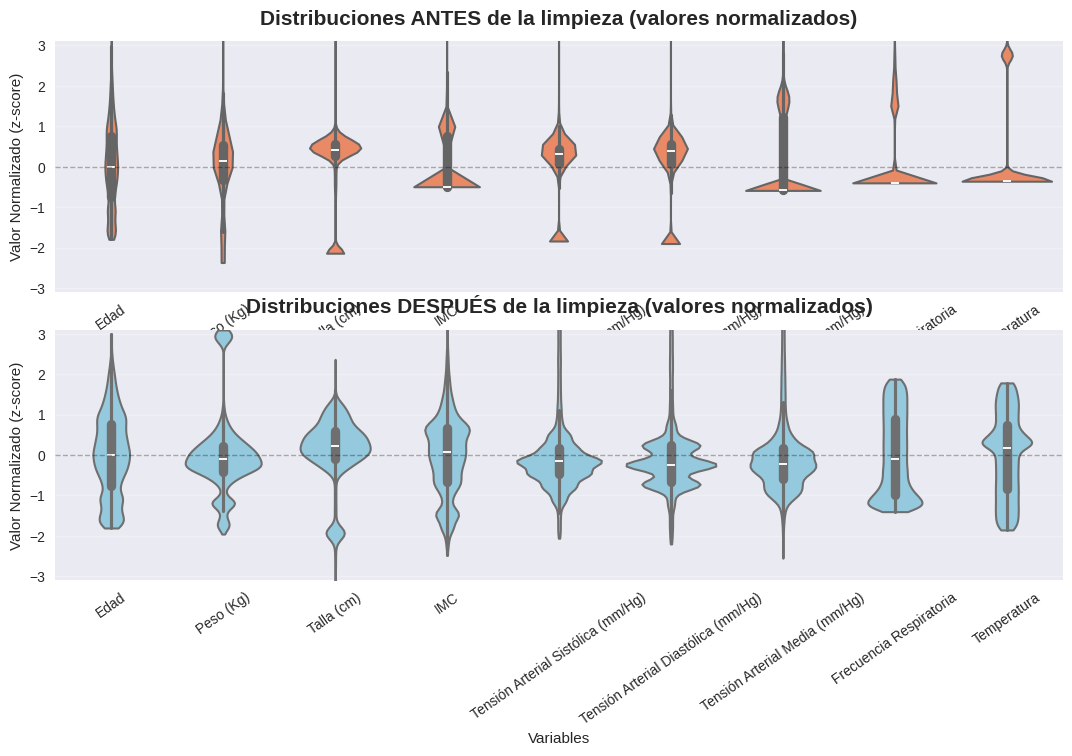

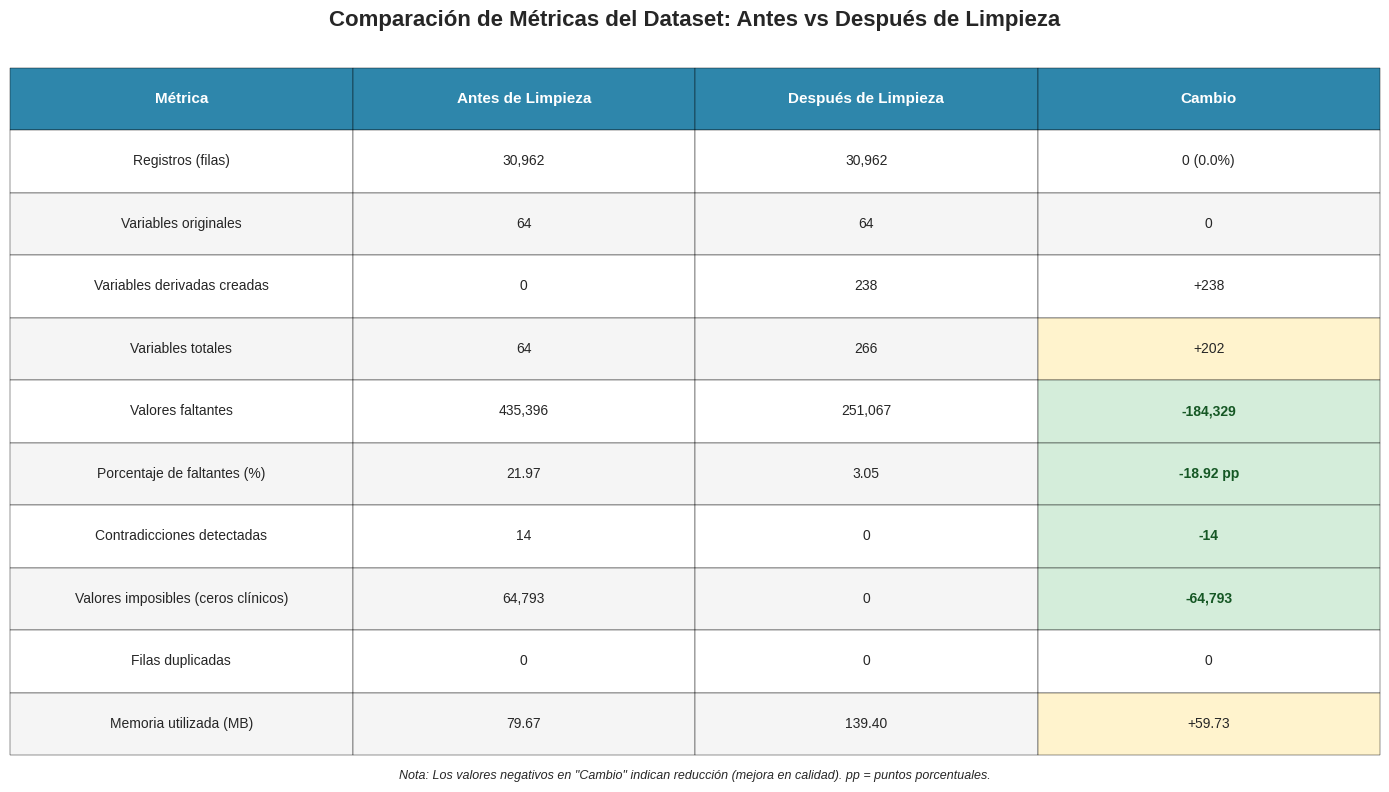

           Sistema                                Top 3 Condiciones (frecuencia)  Variables Codificadas  Total Registros con Condición
      Neurológicos    Trastorno Psiquiátrico (551), Convulsiones (206), TCE (82)                      6                            942
     Respiratorios                          Asma (809), EPOC (88), Neumonía (80)                      5                            981
  Cardiovasculares       Negativo;;;;;;; (13284), H.T.A. (2119), Arritmias (260)                      8                          16172
     Hematológicos   Negativo;;;;;; (27923), Aspirina (509), Transfusiones (405)                      7                          29406
  Endocrinológicos          Negativo;;; (26489), Tiroides (1511), Diabetes (791)                      4                          29542
           Renales Negativo;;; (27834), Litiasis (622), Infección Urinaria (313)                      4                          28930
Gastrointestinales           Negativo;;; (24838), Gastr

In [26]:
numeric_columns = ["Edad",'Peso (Kg)', 'Talla (cm)', 'IMC','Tensión Arterial Sistólica (mm/Hg)', 'Tensión Arterial Diastólica (mm/Hg)', 'Tensión Arterial Media (mm/Hg)', 'Frecuencia Respiratoria', 'Temperatura']

fig = plot_before_after_all_numeric(df, df_clean, numeric_columns)
plt.show()
tabla_metricas = generate_cleaning_summary_table(df, df_clean)
tabla_resumen = get_top_conditions_summary(df, df_clean, top_n=3)
print(tabla_resumen.to_string(index=False))

### Vista de anomalías

#### Funciones

In [27]:
#@title Análisis de anomalías (dataset completo vs sin ceros)
def advanced_eda_pca_clust_anom(dataset, numeric_columns, contamination=0.02, kmeans_k=2, title_prefix=""):
    """
    Aplica PCA 3D, clustering y detección de anomalías a las columnas numéricas de un dataset,
    mostrando todo en subplots compactos.

    Args:
        dataset (pd.DataFrame): El dataset a analizar.
        numeric_columns (list): Lista de columnas numéricas a usar.
        contamination (float): Porcentaje esperado de anomalías para IsolationForest.
        kmeans_k (int): Número de clusters para KMeans.
        title_prefix (str): Prefijo para los títulos de los gráficos (para distinguir datasets).
    """
    import numpy as np
    import plotly.graph_objs as go
    from plotly.subplots import make_subplots
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans
    from sklearn.ensemble import IsolationForest

    # Helper: pick a Plotly supported categorical colorscale (discrete palette)
    def get_discrete_colors(n):
        # Use Plotly qualitative palette
        import plotly.express as px
        base_colors = px.colors.qualitative.Set1 + px.colors.qualitative.Pastel1 + px.colors.qualitative.Pastel2 + px.colors.qualitative.Dark2
        # Repeat if not enough colors
        if n <= len(base_colors):
            return base_colors[:n]
        else:
            return (base_colors * ((n//len(base_colors))+1))[:n]

    # Preprocesamiento: solo filas completas y valores finitos
    X = dataset[numeric_columns].replace([np.inf, -np.inf], np.nan).dropna()
    if len(X) < 3:
        print("No hay suficientes datos válidos para análisis avanzado.")
        return

    print("Tamaño del dataset:", X.shape)

    # Estandarización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA sin limitar componentes para graficar varianza acumulada
    pca_full = PCA()
    pca_full.fit(X_scaled)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

    # Graficar curva de varianza explicada
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
    plt.axhline(y=0.80, color='r', linestyle='--', label='80% de varianza')
    plt.axhline(y=0.90, color='g', linestyle='--', label='90% de varianza')
    plt.xlabel('Número de componentes')
    plt.ylabel('Varianza explicada acumulada')
    plt.title(f'{title_prefix} Curva de varianza explicada por PCA')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Determinar número de componentes para ≥80% y ≥90%
    n_80 = np.argmax(cumulative_variance >= 0.80) + 1
    n_90 = np.argmax(cumulative_variance >= 0.90) + 1
    print(f"{title_prefix} Componentes para ≥80%: {n_80}")
    print(f"{title_prefix} Componentes para ≥90%: {n_90}")

    # PCA con n_components=0.80 para seleccionar automáticamente
    pca = PCA(n_components=0.80, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    explained_var = pca.explained_variance_ratio_.sum()
    n_components_used = pca.n_components_

    print(f"{title_prefix} Varianza explicada PCA: {explained_var:.2%}")
    print(f"{title_prefix} Componentes usados: {n_components_used}")

    # Clustering
    kmeans = KMeans(n_clusters=kmeans_k, n_init=10, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    # Anomalías
    iso = IsolationForest(contamination=contamination, random_state=42)
    anomaly_labels = iso.fit_predict(X_scaled)  # -1 anomalía, 1 normal
    anomalies_mask = anomaly_labels == -1
    print(f"{title_prefix} Anomalías detectadas: {anomalies_mask.sum()} ({anomalies_mask.mean()*100:.1f}%)")

    # Subplots
    subplot_titles = [
        f'{title_prefix}PCA (3D)',
        f'{title_prefix}KMeans (PCA)',
        f'{title_prefix}Anomalías (IsolationForest)'
    ]
    fig = make_subplots(rows=1, cols=3,
                        specs=[[{'type': 'scene'}]*3],
                        subplot_titles=subplot_titles,
                        horizontal_spacing=0.07)
    marker_size = 4 if len(X_pca) > 500 else 6

    # --- PCA puro
    fig.add_trace(
        go.Scatter3d(
            x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2],
            mode='markers',
            marker=dict(size=marker_size, color='royalblue', opacity=0.7),
            name='PCA'
        ),
        row=1, col=1
    )
    # --- KMeans clusters (use explicit color list as Plotly expects for categorical)
    cluster_colors = get_discrete_colors(kmeans_k)
    # Map cluster index to color
    cluster_color_list = [cluster_colors[i] for i in clusters]
    fig.add_trace(
        go.Scatter3d(
            x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2],
            mode='markers',
            marker=dict(size=marker_size, color=cluster_color_list, opacity=0.8),
            name='Clúster'
        ),
        row=1, col=2
    )
    # --- Anomalías
    # Use color mapping: True (anomaly)=red, False (normal)=lightgrey
    ana_color_map = np.where(anomalies_mask, 'red', 'lightgrey')
    fig.add_trace(
        go.Scatter3d(
            x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2],
            mode='markers',
            marker=dict(
                size=marker_size,
                color=ana_color_map,
                showscale=False,
                opacity=0.8
            ),
            name='Anomalía'
        ),
        row=1, col=3
    )

    # Etiquetas de ejes uniformes
    for i in range(1, 4):
        fig['layout'][f'scene{i}']['xaxis']['title'] = 'PC1'
        fig['layout'][f'scene{i}']['yaxis']['title'] = 'PC2'
        fig['layout'][f'scene{i}']['zaxis']['title'] = 'PC3'

    fig.update_layout(
        title=f"{title_prefix}Técnicas avanzadas: PCA, Clustering, Anomalías",
        height=400, width=1100, showlegend=False, margin=dict(t=50, l=10, r=10, b=10)
    )
    fig.show()

    # Recuperar datos originales de anomalías
    anomalous_rows = dataset.loc[X.index[anomalies_mask]].copy()
    anomalous_rows["__anomaly_score"] = -iso.decision_function(X_scaled[anomalies_mask])  # más alto = más anómalo
    anomalous_rows["__anomaly_rank"] = anomalous_rows["__anomaly_score"].rank(ascending=False)

    print(f"\n{title_prefix} Primeras anomalías (ordenadas por score):")
    display(anomalous_rows.sort_values("__anomaly_score", ascending=False).head(5))

    return {
        "X_pca": X_pca,
        "pca_model": pca,
        "cluster_labels": clusters,
        "anomaly_mask": anomalies_mask,
        "anomalous_data": anomalous_rows
    }

#### Resultados

In [ ]:
personal_columns = ['Documento PMD', 'Número de episodio', 'Nombres y Apellidos', 'Tipo de identificación', 'Número de identificación']
df_clean_numeric = df_clean.copy()
df_clean_numeric = df_clean_numeric.drop(columns=personal_columns)
df_clean_numeric = df_clean.select_dtypes(include=[np.number])
result = advanced_eda_pca_clust_anom(df_clean_numeric, numeric_columns=df_clean_numeric.columns, contamination=0.1)
display(result["anomalous_data"].head())

anom = result["anomalous_data"]
normales = df_clean_numeric.loc[~result["anomaly_mask"]]

# Estadísticas por grupo
summary_anom = anom.describe().T
summary_norm = normales.describe().T

# Diferencias absolutas
summary_diff = summary_anom[["mean"]] - summary_norm[["mean"]]
display(summary_diff.sort_values("mean", ascending=False))

anom_scaled = StandardScaler().fit_transform(anom.drop(columns=["__anomaly_score", "__anomaly_rank"]))
anom_abs = np.abs(anom_scaled)
mean_deviation = pd.DataFrame(anom_abs, columns=anom.columns.drop(["__anomaly_score", "__anomaly_rank"])).mean()
display(mean_deviation.sort_values(ascending=False))

X_anom = StandardScaler().fit_transform(anom.drop(columns=["__anomaly_score", "__anomaly_rank"]))
subclusters = KMeans(n_clusters=3, random_state=42).fit_predict(X_anom)
anom["subcluster"] = subclusters
display(anom.groupby("subcluster").mean())

for col in df_clean_numeric.columns:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(normales[col], label="Normal", shade=True)
    sns.kdeplot(anom[col], label="Anómalo", shade=True, color="red")
    plt.title(f"Distribución: {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Deteccion de anomalias y export

In [40]:
def detectar_anomalias_y_exportar(
    df: pd.DataFrame,
    metodo: str = 'isolation_forest',
    contamination: float = 0.5,
    ruta_exportacion: str = '../../OPERA_BASE_clean_con_anomalias.csv',
    random_state: int = 42
) -> pd.DataFrame:
    """
    Detecta anomalías en las filas del dataset y exporta el resultado.
    
    Parámetros:
        df: DataFrame a analizar
        metodo: Método de detección ('isolation_forest' o 'local_outlier_factor')
        contamination: Proporción esperada de anomalías (0.0 a 0.5)
        ruta_exportacion: Ruta donde guardar el dataset con anomalías
        random_state: Semilla para reproducibilidad
    
    Retorna:
        DataFrame con columna 'es_anomalia' agregada (1=anomalía, 0=normal) e incluye 'Documento PMD' al final.
    """
    from sklearn.ensemble import IsolationForest
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.preprocessing import StandardScaler
    
    print("=" * 80)
    print("DETECCIÓN DE ANOMALÍAS")
    print("=" * 80)
    
    df_result = df.copy()
    
    personal_columns = ['Documento PMD', 'Número de episodio', 'Nombres y Apellidos', 'Tipo de identificación', 'Número de identificación']
    
    # Guardar Documento PMD para agregarlo al final
    documento_pmd = df_result['Documento PMD'].reset_index(drop=True)
    
    # Eliminar columnas personales y seleccionar numéricas
    df_result = df_result.drop(columns=personal_columns)
    df_result = df_result.select_dtypes(include=[np.number])
    
    print(f"Filas a analizar: {len(df_result):,}")

    # Manejar valores faltantes (rellenar con cero, igual que antes)
    missing_values = df_result.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    print(f"Valores faltantes: {missing_values}")

    X = df_result.copy()
    X = X.fillna(0)
    
    # Estandarizar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Detectar anomalías
    print(f"\nMétodo: {metodo}")
    print(f"Contamination (proporción esperada de anomalías): {contamination:.1%}")
    
    if metodo == 'isolation_forest':
        detector = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=100
        )
        anomalias = detector.fit_predict(X_scaled)
        df_result['es_anomalia'] = (anomalias == -1).astype(int)
        
    elif metodo == 'local_outlier_factor':
        detector = LocalOutlierFactor(
            contamination=contamination,
            n_neighbors=20
        )
        anomalias = detector.fit_predict(X_scaled)
        df_result['es_anomalia'] = (anomalias == -1).astype(int)
        
    else:
        raise ValueError(f"Método '{metodo}' no reconocido. Use 'isolation_forest' o 'local_outlier_factor'")
    
    # Estadísticas
    total_anomalias = df_result['es_anomalia'].sum()
    porcentaje_anomalias = (total_anomalias / len(df_result)) * 100
    
    print(f"\nRESULTADOS:")
    print(f"  Anomalías detectadas: {total_anomalias:,} ({porcentaje_anomalias:.2f}%)")
    print(f"  Filas normales: {len(df_result) - total_anomalias:,} ({100 - porcentaje_anomalias:.2f}%)")

    # Agregar 'Documento PMD' como última columna
    df_result['Documento PMD'] = documento_pmd.values

    # Exportar
    print(f"\nExportando dataset a: {ruta_exportacion}")
    df_result.to_csv(ruta_exportacion, index=False)
    print("✓ Exportación completada")
    
    print("=" * 80)
    
    return df_result

In [41]:
detectar_anomalias_y_exportar(df_clean, metodo='isolation_forest', ruta_exportacion='../../OPERA_BASE_clean_con_anomalias.csv')

df_pediatricos = df_clean[df_clean['Edad'] < 18]
detectar_anomalias_y_exportar(df_pediatricos, metodo='isolation_forest', ruta_exportacion='../../OPERA_BASE_clean_con_anomalias_PEDIATRICOS.csv')

df_adultos = df_clean[df_clean['Edad'] >= 18]
detectar_anomalias_y_exportar(df_adultos, metodo='isolation_forest', ruta_exportacion='../../OPERA_BASE_clean_con_anomalias_ADULTOS.csv')


DETECCIÓN DE ANOMALÍAS
Filas a analizar: 30,962
Valores faltantes: predicted_score_dx           2095
predicted_score_proc         1103
predicted_score_proc_ant    13229
dtype: int64

Método: isolation_forest
Contamination (proporción esperada de anomalías): 50.0%

RESULTADOS:
  Anomalías detectadas: 15,481 (50.00%)
  Filas normales: 15,481 (50.00%)

Exportando dataset a: ../../OPERA_BASE_clean_con_anomalias.csv
✓ Exportación completada
DETECCIÓN DE ANOMALÍAS
Filas a analizar: 6,683
Valores faltantes: predicted_score_dx           478
predicted_score_proc         225
predicted_score_proc_ant    4162
dtype: int64

Método: isolation_forest
Contamination (proporción esperada de anomalías): 50.0%

RESULTADOS:
  Anomalías detectadas: 3,341 (49.99%)
  Filas normales: 3,342 (50.01%)

Exportando dataset a: ../../OPERA_BASE_clean_con_anomalias_PEDIATRICOS.csv
✓ Exportación completada
DETECCIÓN DE ANOMALÍAS
Filas a analizar: 24,279
Valores faltantes: predicted_score_dx          1617
predicted_scor

,Edad,Peso (Kg),Talla (cm),IMC,Antecedentes anestésicos,Tensión Arterial Sistólica (mm/Hg),Tensión Arterial Diastólica (mm/Hg),Tensión Arterial Media (mm/Hg),Frecuencia Respiratoria,Temperatura,Puntaje Mallampati,anio,mes,dia_semana,Hora_decimal,Sexo_encoded,Atención_encoded,Grupo Sanguíneo_A,Grupo Sanguíneo_AB,Grupo Sanguíneo_B,Grupo Sanguíneo_O,Grupo Sanguíneo_Sin Dato,RH_Negativo,RH_Positivo,RH_Sin Dato,Antecedente neurológicos_convulsiones,Antecedente neurológicos_negativo,Antecedente neurológicos_neoplasia,Antecedente neurológicos_neuropatia,Antecedente neurológicos_tce,Antecedente neurológicos_trastorno psiquiatrico,Antecedente respiratorios_asma,Antecedente respiratorios_epoc,Antecedente respiratorios_negativo,Antecedente respiratorios_negativoneumonia,Antecedente respiratorios_neumonia,Antecedentes cardiovasculares_angina,Antecedentes cardiovasculares_arritmias,Antecedentes cardiovasculares_cardiopatias,Antecedentes cardiovasculares_hta,Antecedentes cardiovasculares_icc,Antecedentes cardiovasculares_infarto,Antecedentes cardiovasculares_negativo,Antecedentes cardiovasculares_valvulopatia,Antecedente hematológicos _anemia,Antecedente hematológicos _anticoagulantes,Antecedente hematológicos _aspirina,Antecedente hematológicos _discrasias,Antecedente hematológicos _negativo,Antecedente hematológicos _plavix,Antecedente hematológicos _transfusiones,Antecedente endocrinológicos_diabetes,Antecedente endocrinológicos_negativo,Antecedente endocrinológicos_obesidad,Antecedente endocrinológicos_tiroides,Antecedente renales_falla renal,Antecedente renales_infeccion urinaria,Antecedente renales_litiasis,Antecedente renales_negativo,Antecedente gastrointestinales_falla hepatica,Antecedente gastrointestinales_gastritis,Antecedente gastrointestinales_negativo,Antecedente gastrointestinales_rge,Anestesia previa_bag,Anestesia previa_bloqueo,Anestesia previa_conductiva,Anestesia previa_desconocido,Anestesia previa_epidural,Anestesia previa_espinal,Anestesia previa_general,Anestesia previa_intraarticular,Anestesia previa_local,Anestesia previa_neuroaxial,Anestesia previa_peribulbar,Anestesia previa_peridural,Anestesia previa_raquidea,Anestesia previa_regional,Anestesia previa_sedacion,Anestesia previa_topica,Examen_Hemoglobina(g/dl),Examen_PT (INR),Examen_Glicemia (mg/dl),Examen_Hematocrito (%),Examen_Plaquetas (ml),Examen_Leucocitos (ml),Examen_PTT,Examen_K (meq/L),Examen_Na (meq/L),Examen_P de O,Cuello Móvil_encoded,Apertura Oral_encoded,Estado Nutricional_encoded,Color de Piel_cianosis,Color de Piel_ictericia,Color de Piel_normal,Color de Piel_palidez,Sistema Nervioso_Sin dato,Sistema Nervioso_agitado,Sistema Nervioso_normal,Sistema Nervioso_par craneal anormal,Sistema Nervioso_sedado,Apertura Visual_encoded,Respuesta Verbal_encoded,Respuesta Motora_encoded,Sistema Respiratorio_auscultacion anormal,Sistema Respiratorio_disnea,Sistema Respiratorio_normal,Sistema Respiratorio_otro,Sistema cardiovascular_galope,Sistema cardiovascular_ingurgitacion yugular,Sistema cardiovascular_normal,Sistema cardiovascular_otro,Sistema cardiovascular_pulso anormal,Sistema cardiovascular_soplo,Abdomen_distension,Abdomen_masas,Abdomen_normal,Abdomen_otro,Arritmia_encoded,Disnea_encoded,Angina_encoded,Condición_alcohol,Condición_embarazo actual,Condición_farmacodependencia,Condición_fumador,Condición_hepatitis b,Condición_hipertermia maligna,Condición_ninguna,Condición_testigo jehova,Condición_vih,Tipo de anestesia propuesta_bloqueo iv,Tipo de anestesia propuesta_bloqueo n,Tipo de anestesia propuesta_general,Tipo de anestesia propuesta_local,Tipo de anestesia propuesta_peridural,Tipo de anestesia propuesta_raquidea,Tipo de anestesia propuesta_sedacion,Tipo de anestesia propuesta_sin dato,Prótesis Dental_fija,Prótesis Dental_movil,Prótesis Dental_no,Alérgeno_alimentos,Alérgeno_ambiental_animales,Alérgeno_contacto_hospitalario,Alérgeno_med_alergias_respiratorio,Alérgeno_med_analgesia_no_opioide,Alérgeno_med_anestesia_y_relajantes,Alérgeno_med_antiinfecciosos